In [2]:
# ============================================================
# セル1: ライブラリのインポートと初期設定
# ============================================================
import pandas as pd
import numpy as np
import ast
import re
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torchdiffeq import odeint_adjoint as odeint
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
import os
import warnings
import pickle
import json
from datetime import datetime
from collections import defaultdict
import time

warnings.filterwarnings('ignore')

# 再現性のためのシード設定
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ============================================================
# セル2: データ前処理関数の定義
# ============================================================
def safe_parse_embedding(x):
    """埋め込みベクトルを柔軟にパースする"""
    if pd.isna(x) or x == "":
        return None
    
    if isinstance(x, (list, np.ndarray)):
        return np.array(x, dtype=np.float32)
    
    if isinstance(x, str):
        try:
            s = re.sub(r'[\[\]\n]', '', x)
            s = s.replace(',', ' ')
            vals = np.array([float(v) for v in s.split() if v], dtype=np.float32)
            return vals if len(vals) > 0 else None
        except Exception:
            return None
    return None

def preprocess_data(file_path):
    """データ前処理のメイン関数"""
    print("1. データ読み込み開始...")
    df = pd.read_csv(file_path)
    
    print("2. 埋め込みベクトルを結合中...")
    combined_vectors = []
    valid_indices = []
    
    for i, row in df.iterrows():
        desc = safe_parse_embedding(row['description_embedding'])
        meta = safe_parse_embedding(row['metadata_embedding'])
        
        if desc is not None and meta is not None:
            combined_vectors.append(np.concatenate([desc, meta]))
            valid_indices.append(i)
        
        if i % 10000 == 0 and i > 0:
            print(f"  {i}件処理済み...")

    if not combined_vectors:
        print("⚠️ ベクトルが生成されません。データの中身を確認してください。")
        return pd.DataFrame()

    df = df.iloc[valid_indices].copy()
    df['combined_vector'] = combined_vectors
    print(f"  結合成功: {len(df)} 件")

    print("3. 追加の前処理（企業名・日付）を実行中...")
    def parse_corp(x):
        try:
            return ast.literal_eval(x) if isinstance(x, str) else x
        except:
            return x
    
    df["corporation"] = df["corporation"].apply(parse_corp)
    df['year_month'] = pd.to_datetime(df['year_month'])
    df = df[(df['year_month'] >= '2010-01-01') & (df['year_month'] <= '2020-12-31')]
    
    if len(df) > 0:
        v_dim = len(df.iloc[0]['combined_vector'])
        print(f"✓ 前処理完了: {len(df)} 件（次元数: {v_dim}）")
    else:
        print("⚠️ 日付フィルタリング後にデータが0件になりました。")
        
    return df


# ============================================================
# セル3: データ前処理の実行
# ============================================================
df = preprocess_data('../dataset/topic_info3.csv')
print(f"\n処理済みデータ形状: {df.shape}")
if len(df) > 0:
    print(f"ベクトル次元数: {len(df.iloc[0]['combined_vector'])}")


# ============================================================
# セル4: 動的グラフ構築関数の定義
# ============================================================
def build_global_graphs(df):
    """動的グラフの構築"""
    all_corporations = sorted(list(set([c for corps in df['corporation'] for c in corps])))
    all_patents = sorted(df['patent_number'].unique().tolist())
    
    corp_to_idx = {corp: i for i, corp in enumerate(all_corporations)}
    patent_to_idx = {patent: i + len(all_corporations) for i, patent in enumerate(all_patents)}
    total_nodes = len(all_corporations) + len(all_patents)
    
    print(f"企業数: {len(all_corporations)}, 特許数: {len(all_patents)}")
    
    # 特許特徴量の準備
    patent_features = {}
    for _, row in df.iterrows():
        patent_features[row['patent_number']] = row['combined_vector']

    global_graph_dict = {}
    year_groups = df.groupby(df['year_month'].dt.year)
    
    # 各年のリンク履歴を保存（Historical Negatives用）
    all_historical_edges = set()
    
    for year, group in year_groups:
        edges = []
        active_nodes = set()
        
        for _, row in group.iterrows():
            p_idx = patent_to_idx[row['patent_number']]
            active_nodes.add(p_idx)
            for corp in row['corporation']:
                c_idx = corp_to_idx[corp]
                edges.append([c_idx, p_idx])
                active_nodes.add(c_idx)
                all_historical_edges.add((c_idx, p_idx))
        
        if not edges:
            continue
        
        # 特徴行列の初期化
        input_dim = len(next(iter(patent_features.values())))
        x = torch.zeros(total_nodes, input_dim)
        for p_num, p_idx in patent_to_idx.items():
            if p_num in patent_features:
                x[p_idx] = torch.tensor(patent_features[p_num])
        
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        active_mask = torch.zeros(total_nodes, dtype=torch.bool)
        active_mask[list(active_nodes)] = True
        
        global_graph_dict[year] = Data(
            x=x, 
            edge_index=edge_index, 
            active_mask=active_mask, 
            year=year,
            num_nodes=total_nodes
        )
        
    return global_graph_dict, all_corporations, all_patents, patent_to_idx, total_nodes, corp_to_idx, all_historical_edges


# ============================================================
# セル5: 動的グラフの構築実行
# ============================================================
graphs, corps, patents, p_map, total_n, c_map, historical_edges = build_global_graphs(df)
num_corps = len(corps)

print(f"\n構築完了:")
print(f"  総ノード数: {total_n}")
print(f"  企業数: {num_corps}")
print(f"  特許数: {len(patents)}")
print(f"  年数: {len(graphs)}")
print(f"  年度: {sorted(graphs.keys())}")
print(f"  履歴エッジ数: {len(historical_edges)}")


# ============================================================
# セル6: 新しい評価指標の実装（MRR, Hits@K）
# ============================================================
def compute_ranking_metrics(model, z_pred, pos_edges, num_corps, all_true_edges, k_values=[1, 3, 10, 50]):
    """
    Filtered MRRとHits@Kを計算する関数
    all_true_edges: 学習・検証・テストに含まれる全正解エッジの (src, dst) セット
    """
    model.eval()
    if pos_edges.size(1) == 0:
        return None
    
    # アクティブな企業と特許を取得
    active_corps = torch.unique(pos_edges[0][pos_edges[0] < num_corps])
    active_patents = torch.unique(pos_edges[1][pos_edges[1] >= num_corps])
    
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    reciprocal_ranks = []
    hits_at_k = {k: [] for k in k_values}
    
    # 計算効率のため最大1000個
    num_eval = min(pos_edges.size(1), 1000)

    # 各正例エッジについてランキングを計算
    for i in range(min(pos_edges.size(1), 1000)):  # 計算効率のため最大1000個
        src, dst = pos_edges[0, i].item(), pos_edges[1, i].item()
        filtered_negs = []
        attempts = 0
        #99個の「真のふれい（どのデータセットにも存在しないエッジ）」を探す

        # 負例候補を生成（同じ企業から他の特許へのリンク）
        neg_candidates = active_patents[active_patents != dst]
        if len(neg_candidates) < 99:
            continue
        
        # ランダムに99個サンプリング
        while len(filtered_negs) < 99 and attempts < 1000:
            neg_dst = active_patents[torch.randint(len(active_patents), (1,))].item()
            # ターゲット(src, dst)そのものではなく、かつ全正解データに含まれていない場合のみ採用
            if neg_dst != dst and (src, neg_dst) not in all_true_edges:
                filtered_negs.append(neg_dst)
            attempts += 1
        
        if len(filtered_negs) < 99:
            continue # 負例が十分に確保できない場合はスキップ
            
        # 正例1個 + 負例99個
        all_dsts = torch.tensor([dst] + filtered_negs, device=device)
        src_repeated = torch.tensor([src] * len(all_dsts), device=device)
        candidate_edges = torch.stack([src_repeated, all_dsts])
        
        with torch.no_grad():
            scores = model.decode(z_pred, candidate_edges).cpu().numpy()
        
        # 順位計算（高いスコアほど上位）
        rank = (scores > scores[0]).sum() + 1
        reciprocal_ranks.append(1.0 / rank)
        
        for k in k_values:
            hits_at_k[k].append(1.0 if rank <= k else 0.0)
    
    if not reciprocal_ranks:
        return None
    
    metrics = {'mrr': np.mean(reciprocal_ranks), 'num_samples': len(reciprocal_ranks)}
    for k in k_values:
        metrics[f'hits@{k}'] = np.mean(hits_at_k[k])
    
    return metrics

/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /home/nakamuraroi/.local/lib/python3.8/site-packages/torch_sparse/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
/home/nakamuraroi/.local/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook imp

Using device: cuda
1. データ読み込み開始...
2. 埋め込みベクトルを結合中...
  10000件処理済み...
  20000件処理済み...
  30000件処理済み...
  40000件処理済み...
  結合成功: 42789 件
3. 追加の前処理（企業名・日付）を実行中...
✓ 前処理完了: 19389 件（次元数: 1088）

処理済みデータ形状: (19389, 20)
ベクトル次元数: 1088
企業数: 2450, 特許数: 19384

構築完了:
  総ノード数: 21834
  企業数: 2450
  特許数: 19384
  年数: 11
  年度: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
  履歴エッジ数: 27274


In [41]:
# ============================================================
# セル9: エンコーダ定義 (既存のまま)
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# ============================================================
# セル10 (修正): 高解像度・安定化したPotentialNet
# ============================================================
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()

        # 空間の解像度を上げるためのランダム周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim
        
        # 層を深くし、Dropoutを加えることで一方向の単純な壁になるのを防ぐ
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, z):
        # 座標 z を高周波に変換することで「島」を作りやすくする
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        with torch.no_grad():
            potentials = self.forward(grid_points)
        
        return X.cpu().numpy(), Y.cpu().numpy(), potentials.view(resolution, resolution).cpu().numpy()
    
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device, requires_grad=True
        )
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# セル11: 統合VGAEモデル (Gradient ODE専用)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, hidden_dim=256,
                 latent_dim=2, sequence_length=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.sequence_length = sequence_length

        self.corp_embeddings = nn.Embedding(num_corps, input_dim)
        nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        # node_indicesが指定されていない場合は全ノードを対象にする
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        # 企業ノードに該当するインデックスのみを抽出
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
        # マスクではなく、抽出したインデックスを直接使って埋め込みを代入
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        return torch.sigmoid(self.link_predictor(torch.cat([z[edge_index[0]], z[edge_index[1]]], dim=-1))).squeeze()

    def predict_future(self, z_history_list):
        return self.temporal_predictor(z_history_list[-1])
# ============================================================
# セル12: 負例サンプリング関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    """
    潜在空間上で『近くにいるのにリンクがない』ノードを優先的に負例として選ぶ。
    これにより、中心部で固まっているノードを引き剥がす力が最大化される。
    """
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    
    # 1. 候補ペアを多めにランダム生成 (例: 要求数の5倍)
    # 全くのランダムではなく、現在のアクティブなノードから選ぶ
    candidate_indices_corp = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    candidate_indices_pat = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 2. 候補ペアの潜在空間上の距離を計算
    # 距離が近いほど『紛らわしい（Hard）』と判断し、引き離す対象にする
    z_c = z[candidate_indices_corp]
    z_p = z[candidate_indices_pat]
    dists = torch.norm(z_c - z_p, dim=1)
    
    # 3. 距離が近い順（昇順）にソート
    sorted_indices = torch.argsort(dists)
    
    # 4. 近いものから順に、正例でも履歴でもないものを採用
    for idx in sorted_indices:
        c_node = candidate_indices_corp[idx].item()
        p_node = candidate_indices_pat[idx].item()
        edge = (c_node, p_node)
        
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c_node, p_node])
            if len(neg_edges) >= num_samples:
                break
                
    if len(neg_edges) == 0:
        return None
        
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()


# ============================================================
# セル13 (完全修正版): 損失関数
# ============================================================
def compute_loss_standardized(model, data_t, data_t1, num_corps, 
                              z_history_for_prediction, historical_edges,
                              beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=1.0,
                              potential_weight=0.5, repulsion_weight=5.0):
    """
    統合損失関数
    
    Args:
        model: UnifiedVGAE
        data_t: 現在時刻のグラフデータ
        data_t1: 次時刻のグラフデータ
        num_corps: 企業数
        z_history_for_prediction: リスト [z_{t-2}, z_{t-1}, z_t]
        historical_edges: 履歴エッジのセット
        
    Returns:
        total_loss: スカラー損失
        loss_dict: 各損失の辞書
    """
    try:
        device = data_t.x.device
        node_indices = torch.arange(model.num_nodes, device=device)
        
        # ============================================================
        # 1. 現在時刻 t のエンコード
        # ============================================================
        z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index, node_indices)
        
        # ============================================================
        # 2. 再構成損失 (現在時刻 t)
        # ============================================================
        pos_edge_index_t = data_t.edge_index
        active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
        active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
        pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
        
        neg_edge_index_t = sample_hard_negatives_v2(
            model, z_t, active_corps_t, active_patents_t, 
            pos_set_t, historical_edges, num_samples=500
        )
        
        recon_loss_t = torch.tensor(0.0, device=device)
        if neg_edge_index_t is not None and neg_edge_index_t.size(1) > 0:
            pos_pred_t = model.decode(z_t, pos_edge_index_t)
            neg_pred_t = model.decode(z_t, neg_edge_index_t)
            recon_loss_t = (
                -torch.log(pos_pred_t + 1e-15).mean() * pos_weight 
                - torch.log(1 - neg_pred_t + 1e-15).mean()
            )
        
        # KL損失
        kl_loss_t = -0.5 * torch.mean(
            1 + logvar_t[data_t.active_mask] 
            - mu_t[data_t.active_mask].pow(2) 
            - logvar_t[data_t.active_mask].exp()
        )
        
        # ============================================================
        # 3. ポテンシャル損失（ランクベース）
        # ============================================================
        unique_patents, counts = torch.unique(data_t.edge_index[1], return_counts=True)
        target_phi = torch.zeros(model.num_nodes, 1, device=device)

        # ここで patent_mask を定義する
        patent_mask = (node_indices >= num_corps) & data_t.active_mask

        potential_loss = torch.tensor(0.0, device=device)
        if unique_patents.numel() > 0:
            # ランク計算 (人気なほど大きな値)
            ranks = torch.argsort(torch.argsort(counts.float())).float()
            # 0〜1に正規化後、1.0(不人気/山) 〜 -1.0(人気/谷) に変換
            normalized_target = 1.0 - (ranks / (ranks.max() + 1e-9)) * 2.0
            target_phi[unique_patents] = normalized_target.view(-1, 1)

            predicted_phi = model.temporal_predictor.potential_net(mu_t)
            # アクティブな特許ノードのみで損失を計算
            potential_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])
        
        # ============================================================
        # 4. 未来予測損失（重要な修正箇所）
        # ============================================================
        # z_history_for_prediction がリストであることを確認
        z_t1_pred = model.predict_future(z_history_for_prediction)
        with torch.no_grad():
            _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)

        # 予測位置と実際の次時刻位置のMSE
        latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

        # ============================================================
        # 5. 未来リンク予測損失
        # ============================================================
        pos_edge_index_t1 = data_t1.edge_index
        future_link_loss = torch.tensor(0.0, device=device)
        
        if pos_edge_index_t1.size(1) > 0 and z_history_for_prediction is not None:
            active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
            active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
            pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
            
            neg_t1 = sample_hard_negatives_v2(
                model, z_t1_pred, active_corps_t1, active_patents_t1, 
                pos_set_t1, historical_edges, num_samples=300
            )
            
            if neg_t1 is not None and neg_t1.size(1) > 0:
                future_link_loss = (
                    -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight
                    - torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()
                )

        # ============================================================
        # 6. 特許間反発力損失 (修正版)
        # ============================================================
        # 全ノードに適用すると企業-特許間の引き寄せと衝突するため、特許ノード同士のみに限定
        patent_mask = (node_indices >= num_corps) & data_t.active_mask
        z_patents = z_t[patent_mask]

        repulsion_loss = torch.tensor(0.0, device=device)
        if z_patents.size(0) > 1:
            dist_matrix = torch.cdist(z_patents, z_patents)
            margin = 0.5
            eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
            repulsion_loss = torch.relu(margin - dist_matrix[eye_mask]).mean()

        # ============================================================
        # 6. 総損失
        # ============================================================

        total_loss = (
            recon_loss_t 
            + beta * kl_loss_t 
            + latent_pred_weight * latent_pred_loss 
            + future_link_weight * future_link_loss 
            + potential_weight * potential_loss
            + repulsion_weight * repulsion_loss 
        )
        
        loss_dict = {
            'total_loss': total_loss.item(),
            'recon_loss': recon_loss_t.item(),
            'kl_loss': kl_loss_t.item(),
            'latent_pred_loss': latent_pred_loss.item(),
            'future_link_loss': future_link_loss.item(),
            'potential_loss': potential_loss.item(),
            'repulsion_loss': repulsion_loss.item()
        }
        
        return total_loss, loss_dict
        
    except Exception as e:
        print(f"⚠️ 損失計算エラー: {e}")
        return (torch.tensor(0.0, device=device, requires_grad=True), 
                {'total_loss': 0.0, 'potential_loss': 0.0, 'future_link_loss': 0.0})


def train_model_improved(model, global_graph_dict, num_corps, model_name, 
                        historical_edges, num_epochs=20):
    """
    エビデンス指標（分離度・理論一致度）を統合した改善版学習ループ
    """
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.7)]
    val_years = years[int(len(years) * 0.7):int(len(years) * 0.85)]
    test_years = years[int(len(years) * 0.85):]
    
    # 指標を保存するための履歴
    history = {
        'train_loss': [], 
        'val_mrr': [], 
        'dispersion': [], # 空間分散度
        'consistency': [] # 理論一致度
    }
    
    # 全正解エッジの収集（既存のまま）
    all_true_edges = set()
    for year_list in [train_years, val_years, test_years]:
        for year in year_list:
            edges = global_graph_dict[year].edge_index.t().tolist()
            all_true_edges.update([tuple(e) for e in edges])
    
    best_val_mrr = 0.0
    best_model_state = None
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        
        # --- 学習：年ごとのループ ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 1. 履歴の構築と現在の z_t の取得
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    data_hist = global_graph_dict[train_years[j]].to(device)
                    z_hist, _, _ = model.encode(data_hist.x, data_hist.edge_index)
                    z_history.append(z_hist)
            
            z_t = z_history[-1] # 現在の位置

            # 2. 損失計算
            optimizer.zero_grad()
            loss, loss_dict = compute_loss_standardized(
                model, data_t, data_t1, num_corps, 
                z_history, historical_edges
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1

            # 3. エビデンス指標の計算（エポックの最後の年で計測）
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t1_pred = model.predict_future(z_history) # 1年後の予測位置
                    evidence = calculate_evidence_metrics(model, data_t, z_t, z_t1_pred)
                    history['dispersion'].append(evidence['dispersion'])
                    history['consistency'].append(evidence['physical_consistency'])
        
        avg_train_loss = epoch_loss / max(num_batches, 1)
        history['train_loss'].append(avg_train_loss)
        
        # --- 検証フェーズ（既存のまま） ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            z_history_val = []
            look_back_years = [y for y in years if y < year_t1][-3:]
            for y in look_back_years:
                with torch.no_grad():
                    data_hist = global_graph_dict[y].to(device)
                    z_h, _, _ = model.encode(data_hist.x, data_hist.edge_index)
                    z_history_val.append(z_h)
            with torch.no_grad():
                z_pred = model.predict_future(z_history_val)
            metrics = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
            if metrics: val_mrr_list.append(metrics['mrr'])
        
        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        if val_mrr > best_val_mrr:
            best_val_mrr = val_mrr
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        scheduler.step(val_mrr)
        
        # --- ログ出力の強化：損失とエビデンスを同時に表示 ---
        print(f"Epoch {epoch+1:02d}/{num_epochs} | "
              f"Loss: {avg_train_loss:.4f} | "
              f"MRR: {val_mrr:.4f} | "
              f"Disp: {history['dispersion'][-1]:.3f} | "
              f"Consist: {history['consistency'][-1]:.3f}")
    
    if best_model_state:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    
    return model, best_val_mrr, history, time.time() - start_time

# ============================================================
# セル13 (修正版): ランクベース順位制を用いた損失関数
# ============================================================
def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=15.0,
                              potential_weight=10.0, repulsion_weight=5.0):
    device = data_t.x.device
    
    # 0. インデックスとマスクの定義
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失 (t)
    pos_edge_index_t = data_t.edge_index
    active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
    active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
    pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
    
    neg_edge_index_t = sample_hard_negatives_v2(model, z_t, active_corps_t, active_patents_t, 
                                                pos_set_t, historical_edges, num_samples=500)
    
    recon_loss_t = torch.tensor(0.0, device=device)
    if neg_edge_index_t is not None:
        pos_pred_t = model.decode(z_t, pos_edge_index_t)
        neg_pred_t = model.decode(z_t, neg_edge_index_t)

        # 【修正箇所】ハブ対策：次数計算の修正
        node_degrees = torch.zeros(model.num_nodes, device=device)
        # edge_index.view(-1) は [エッジ数*2] なので、ones もそのサイズに合わせる
        flat_indices = data_t.edge_index.view(-1)
        ones = torch.ones(flat_indices.size(0), device=device)
        node_degrees.index_add_(0, flat_indices, ones)
        node_degrees += 2.0 
        
        u_idx, v_idx = pos_edge_index_t[0], pos_edge_index_t[1]
        edge_rarity = 1.0 / torch.log(node_degrees[u_idx] * node_degrees[v_idx] + 1e-15)
        
        recon_loss_t = (
            -(torch.log(pos_pred_t + 1e-15) * edge_rarity).mean() * pos_weight 
            - torch.log(1 - neg_pred_t + 1e-15).mean()
        )

    # KL損失
    kl_loss_t = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # 3. ポテンシャル学習
    unique_patents, counts = torch.unique(data_t.edge_index[1], return_counts=True)
    target_phi = torch.zeros(model.num_nodes, 1, device=device)
    potential_loss = torch.tensor(0.0, device=device)
    
    if unique_patents.numel() > 0:
        ranks = torch.argsort(torch.argsort(counts.float())).float()
        normalized_target = 1.0 - (ranks / (ranks.max() + 1e-9)) * 2.0
        target_phi[unique_patents] = normalized_target.view(-1, 1)
        
        predicted_phi = model.temporal_predictor.potential_net(mu_t)
        potential_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    pos_edge_index_t1 = data_t1.edge_index
    future_link_loss = torch.tensor(0.0, device=device)
    if pos_edge_index_t1.size(1) > 0:
        active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_corps_t1, active_patents_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失
    z_patents = z_t[patent_mask]
    repulsion_loss = torch.tensor(0.0, device=device)
    if z_patents.size(0) > 1:
        dist_matrix = torch.cdist(z_patents, z_patents)
        margin = 0.5
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(margin - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss_t 
                  + beta * kl_loss_t 
                  + latent_pred_weight * latent_pred_loss 
                  + future_link_weight * future_link_loss 
                  + potential_weight * potential_loss
                  + repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total_loss': total_loss.item(), 
        'potential_loss': potential_loss.item(), 
        'future_link_loss': future_link_loss.item(),
        'repulsion_loss': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """
    エビデンスとしての正しさを定量化する指標を算出
    """
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # --- 指標1: 空間分散度 (Spatial Dispersion) ---
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # --- 指標2: 物理的一致度 (Cosine Similarity to Gradient) ---
    # 1. ODEによる実際の移動ベクトル
    v_actual = z_fut_active - z_active
    
    # 2. ポテンシャル場から計算される理論上の引力ベクトル (-grad Phi)
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    # 3. 2つのベクトルの向きの一致度 (Cosine Similarity)
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    # --- 指標3: 谷への収束率 (Potential Drop) ---
    # 移動によってポテンシャルがどれだけ下がったか（＝より活性領域へ近づいたか）
    with torch.no_grad():
        phi_now = model.temporal_predictor.potential_net(z_active)
        phi_future = model.temporal_predictor.potential_net(z_fut_active)
        # ポテンシャルが低下（エネルギー安定）した割合
        drop_rate = torch.mean((phi_now - phi_future) / (torch.abs(phi_now) + 1e-6)).item()

    return {
        "dispersion": dispersion,         # 数値が大きいほど分離が良い
        "physical_consistency": avg_consistency, # 1.0に近いほど理論通り
        "potential_convergence": drop_rate # 正の値なら「谷に向かって移動」している
    }

# ============================================================
# メイン実行：Gradient Neural ODE のみの学習
# ============================================================
print(">>> Gradient Neural ODE の学習を開始します...")

model_gradient_ode = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=len(df.iloc[0]['combined_vector']),
    hidden_dim=128, latent_dim=2, sequence_length=3
).to(device)

trained_model_gradient_ode, best_mrr_gradient_ode, history_gradient_ode, time_gradient_ode = train_model_improved(
    model_gradient_ode, graphs, num_corps, "VGAE+GradientODE_RankBased", historical_edges, num_epochs=30
)

print(f"\n学習完了: VGAE + Gradient ODE (順位制ターゲット)")
print(f"Best Validation MRR: {best_mrr_gradient_ode:.4f}")

>>> Gradient Neural ODE の学習を開始します...
Epoch 01/30 | Loss: 66.0243 | MRR: 0.0510 | Disp: 29.036 | Consist: 0.945
Epoch 02/30 | Loss: 58.7998 | MRR: 0.0558 | Disp: 22.187 | Consist: 0.948
Epoch 03/30 | Loss: 52.2335 | MRR: 0.0585 | Disp: 19.070 | Consist: 0.956
Epoch 04/30 | Loss: 46.0196 | MRR: 0.0542 | Disp: 15.382 | Consist: 0.953
Epoch 05/30 | Loss: 41.8361 | MRR: 0.0626 | Disp: 17.288 | Consist: 0.958
Epoch 06/30 | Loss: 41.7458 | MRR: 0.0583 | Disp: 16.652 | Consist: 0.962
Epoch 07/30 | Loss: 39.7987 | MRR: 0.0601 | Disp: 12.926 | Consist: 0.946
Epoch 08/30 | Loss: 37.9728 | MRR: 0.0531 | Disp: 16.283 | Consist: 0.957
Epoch 09/30 | Loss: 35.9156 | MRR: 0.0519 | Disp: 16.671 | Consist: 0.967
Epoch 10/30 | Loss: 37.1190 | MRR: 0.0517 | Disp: 13.832 | Consist: 0.967
Epoch 11/30 | Loss: 36.7537 | MRR: 0.0510 | Disp: 9.861 | Consist: 0.963
Epoch 12/30 | Loss: 35.4525 | MRR: 0.0543 | Disp: 12.586 | Consist: 0.966
Epoch 13/30 | Loss: 34.8764 | MRR: 0.0527 | Disp: 11.511 | Consist: 0.964
Ep

In [42]:
best_mrr_gradient_ode

0.06258916953079115

In [43]:
history_gradient_ode

{'train_loss': [66.02434158325195,
  58.79976717631022,
  52.23347473144531,
  46.01956303914388,
  41.83612887064616,
  41.745771408081055,
  39.7986863454183,
  37.9728094736735,
  35.91560618082682,
  37.118964513142906,
  36.753729502360024,
  35.452466328938804,
  34.87640508015951,
  35.29647127787272,
  34.06440989176432,
  33.56590334574381,
  32.6419407526652,
  32.40552965799967,
  31.086299896240234,
  33.3093147277832,
  32.78341865539551,
  32.533504803975426,
  32.34003225962321,
  31.89586607615153,
  31.364827156066895,
  30.946152051289875,
  31.847535133361816,
  30.753708839416504,
  30.778690973917644,
  31.01755936940511],
 'val_mrr': [0.05103547213264815,
  0.05579623542219308,
  0.05850295832676738,
  0.05422313389674727,
  0.06258916953079115,
  0.05831188878664647,
  0.06013428591171855,
  0.05307188921340334,
  0.051886615381620885,
  0.05172661387334097,
  0.05098120363230159,
  0.05428105806160879,
  0.0526896668848026,
  0.05112294940316218,
  0.05288851781

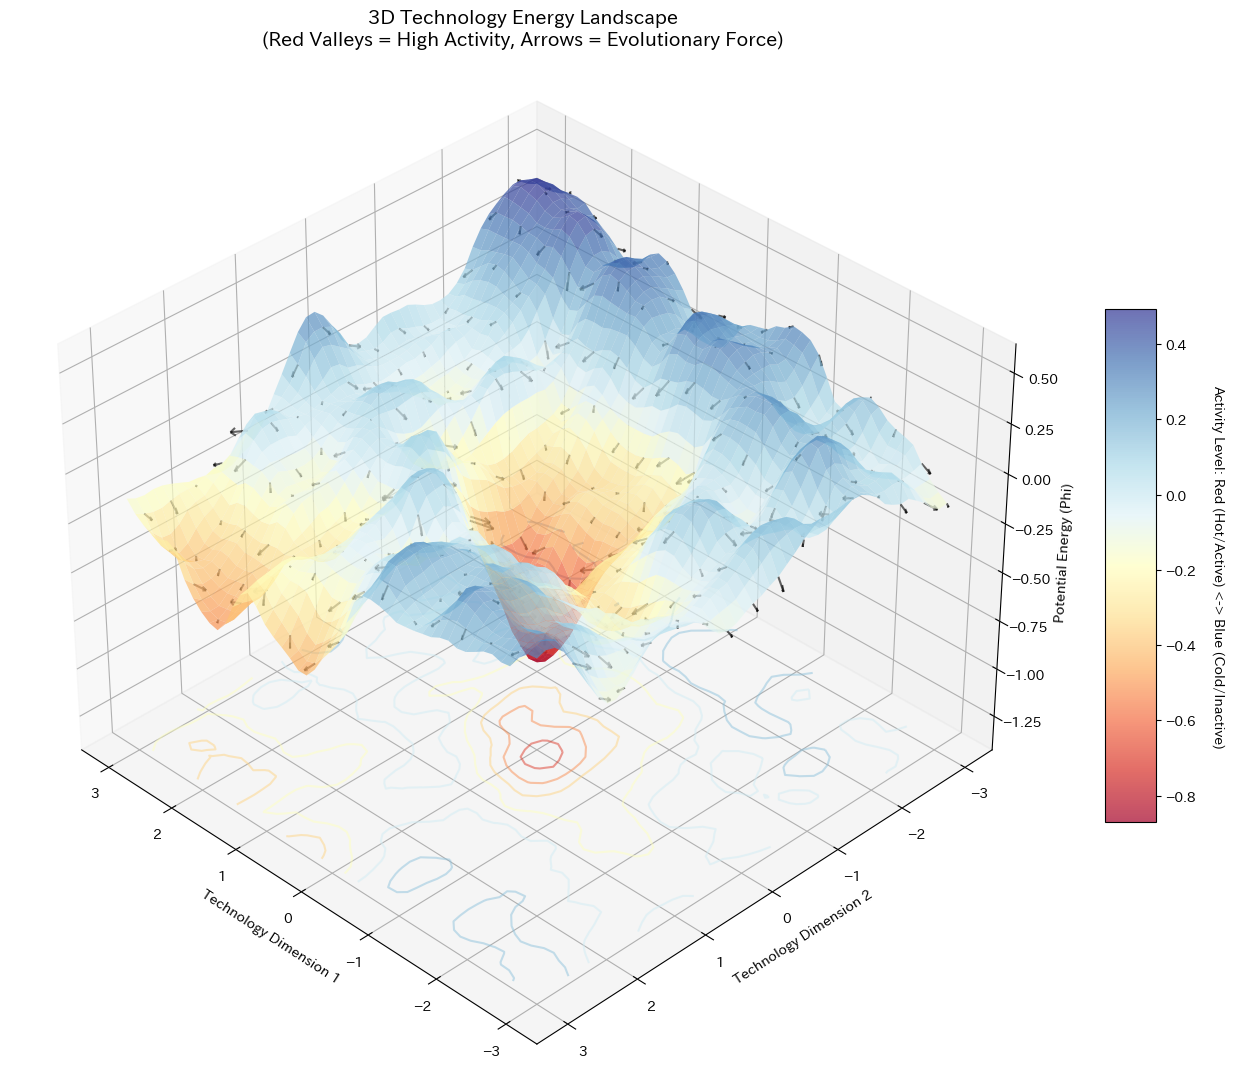

In [44]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_potential_3d_quiver_only(model, device, res=50, range_lim=3.0):
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    
    # 1. グリッド生成
    x = np.linspace(-range_lim, range_lim, res)
    y = np.linspace(-range_lim, range_lim, res)
    X, Y = np.meshgrid(x, y)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    # latent_dimに合わせて入力整形
    if model.latent_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
        grid_input = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input = grid_tensor

    # 2. ポテンシャルと勾配の計算
    grid_input.requires_grad_(True)
    phi = potential_net(grid_input)
    # gradsは dPhi/dz (上り坂の方向)
    grads = torch.autograd.grad(phi.sum(), grid_input)[0]
    
    # 【修正1】高さデータの変更
    # -phi ではなく phi そのままを使う（人気=-1.0/谷, 不人気=1.0/山）
    Z_display = phi.detach().cpu().numpy().reshape(res, res)

    # 【修正2】ベクトルの向きの変更
    # 物理的な引力（下り坂の方向）を表現するため、マイナスをかける (-grad Phi)
    U = -grads[:, 0].detach().cpu().numpy().reshape(res, res)
    V = -grads[:, 1].detach().cpu().numpy().reshape(res, res)
    
    # 【修正3】垂直方向の演出
    # 谷に吸い込まれるような視覚効果を出すため、Wを負の勾配強度に
    W = -np.sqrt(U**2 + V**2) * 0.2

    # 4. プロット
    fig = plt.figure(figsize=(14, 11))
    ax = fig.add_subplot(111, projection='3d')

    # 地形の描画: RdYlBu (数値が低い=-1/谷=Red, 数値が高い=1/山=Blue)
    surf = ax.plot_surface(X, Y, Z_display, cmap='RdYlBu', alpha=0.7, 
                       edgecolor='none', antialiased=True, shade=True)

    # 底面への等高線投影
    offset = np.min(Z_display) - 0.5
    ax.contour(X, Y, Z_display, zdir='z', offset=offset, cmap='RdYlBu', alpha=0.5)  

    # ベクトル（引力場）の表示
    skip = 3 
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Z_display[::skip, ::skip],
              U[::skip, ::skip], V[::skip, ::skip], W[::skip, ::skip],
              length=0.2, color='black', alpha=0.6, pivot='tail', arrow_length_ratio=0.3)

    # 5. 仕上げ
    ax.set_zlim(offset, np.max(Z_display) + 0.1)
    ax.set_title("3D Technology Energy Landscape\n(Red Valleys = High Activity, Arrows = Evolutionary Force)", fontsize=14)
    ax.set_xlabel("Technology Dimension 1")
    ax.set_ylabel("Technology Dimension 2")
    ax.set_zlabel("Potential Energy (Phi)")

    # カラーバーのラベルを分かりやすく変更
    cbar = fig.colorbar(surf, shrink=0.5, aspect=10)
    cbar.set_label('Activity Level: Red (Hot/Active) <-> Blue (Cold/Inactive)', rotation=270, labelpad=20)
    
    ax.view_init(elev=35, azim=135)
    plt.tight_layout()
    plt.show()

# 実行
visualize_potential_3d_quiver_only(trained_model_gradient_ode, device)

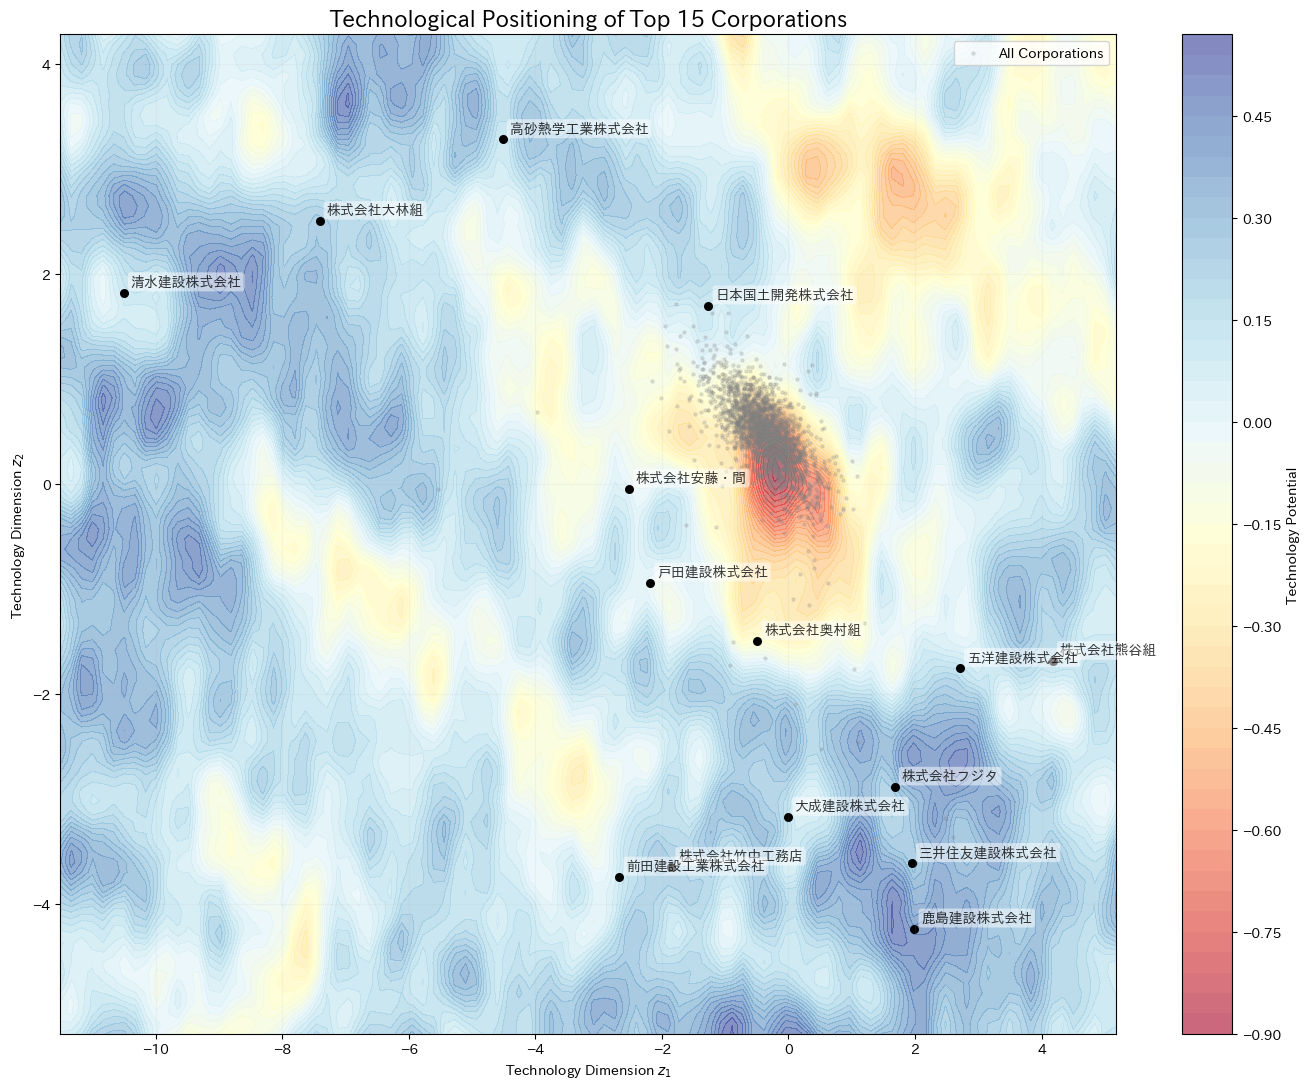

In [45]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def visualize_potential_2d_with_labels(model, data_t, c_map, device, top_k=15, range_lim=3.0):
    """
    2Dマップの上に主要企業のラベルを重ねて表示する
    """
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    
    # 1. 最新の埋め込み座標を取得
    with torch.no_grad():
        z, _, _ = model.encode(data_t.x.to(device), data_t.edge_index.to(device))
    z_np = z.cpu().numpy()

    # 2. 主要企業（次数が高い企業）の抽出
    # data_t.edge_index[0] は企業ノードのインデックス
    unique_corps, counts = torch.unique(data_t.edge_index[0], return_counts=True)
    top_indices = unique_corps[torch.argsort(counts, descending=True)[:top_k]].cpu().numpy()
    
    # 逆引きマップ（インデックス -> 企業名）
    idx_to_corp = {idx: name for name, idx in c_map.items()}

    # 3. 背景ポテンシャル場の計算
    res = 100
    # データの最小・最大値から範囲を自動決定（少し余白を持たせる）
    x_min, x_max = z_np[:, 0].min() - 1, z_np[:, 0].max() + 1
    y_min, y_max = z_np[:, 1].min() - 1, z_np[:, 1].max() + 1
    
    # グリッド生成をこの範囲で行う
    x_1d = np.linspace(x_min, x_max, 100)
    y_1d = np.linspace(y_min, y_max, 100)
    X, Y = np.meshgrid(x_1d, y_1d)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        if model.latent_dim > 2:
            padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
            phi = potential_net(torch.cat([grid_tensor, padding], dim=-1))
        else:
            phi = potential_net(grid_tensor)
    Z = phi.cpu().numpy().reshape(res, res)

    # 4. プロット
    plt.figure(figsize=(14, 11))
    
    # A. ポテンシャル場
    contour = plt.contourf(X, Y, Z, levels=50, cmap='RdYlBu', alpha=0.6)
    plt.colorbar(contour, label='Technology Potential')

    # B. 全企業の散布図（薄く表示）
    plt.scatter(z_np[:model.num_corps, 0], z_np[:model.num_corps, 1], 
                c='gray', s=5, alpha=0.2, label='All Corporations')

    # C. 主要企業のラベル付け
    for idx in top_indices:
        name = idx_to_corp[idx]
        x, y = z_np[idx, 0], z_np[idx, 1]
        
        # 点を打つ
        plt.scatter(x, y, c='black', s=30)
        # テキストラベルを追加（少しずらして表示）
        plt.annotate(name, (x, y), xytext=(5, 5), textcoords='offset points',
                     fontsize=10, fontweight='bold', alpha=0.8,
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.5, ec='none'))

    # 5. 仕上げ
    plt.title(f"Technological Positioning of Top {top_k} Corporations", fontsize=16)
    plt.xlabel("Technology Dimension $z_1$")
    plt.ylabel("Technology Dimension $z_2$")
    plt.grid(alpha=0.1)
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# 実行（最新の年のデータを使用）
last_year = sorted(graphs.keys())[-1]
visualize_potential_2d_with_labels(trained_model_gradient_ode, graphs[last_year], c_map, device)

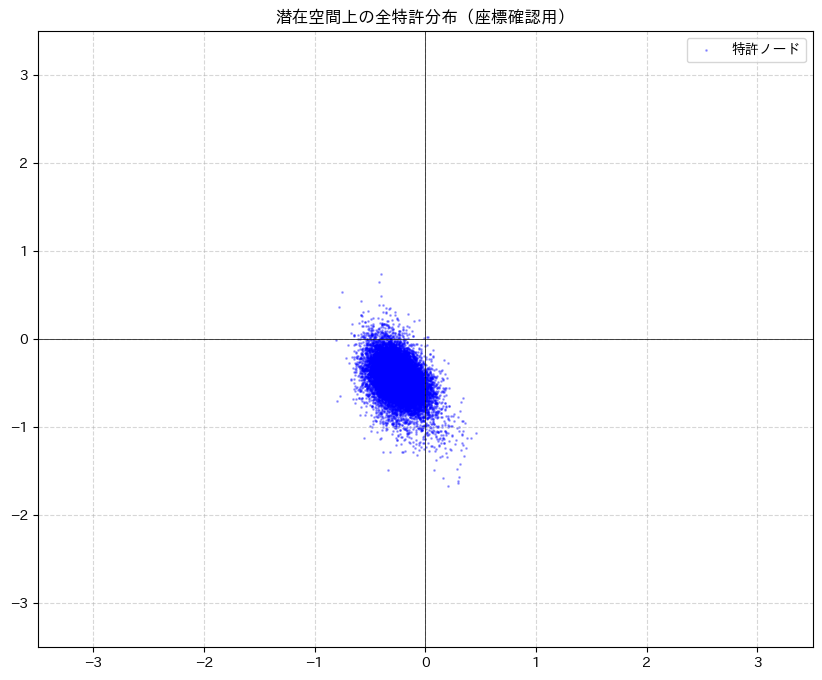

In [46]:
def check_patent_distribution(model, df, device, range_lim=3.5):
    model.eval()
    # 全特許の座標を計算
    patent_vectors = torch.stack([torch.tensor(v) for v in df['combined_vector'].values]).to(device)
    with torch.no_grad():
        mu, _ = model.encoder(patent_vectors, torch.zeros((2, 0), dtype=torch.long).to(device))
        coords = mu.cpu().numpy()

    plt.figure(figsize=(10, 8))
    # 背景なしで、点（点）だけをプロット
    plt.scatter(coords[:, 0], coords[:, 1], s=1, alpha=0.3, c='blue', label='特許ノード')
    
    plt.axhline(0, color='black', lw=0.5)
    plt.axvline(0, color='black', lw=0.5)
    plt.xlim(-range_lim, range_lim)
    plt.ylim(-range_lim, range_lim)
    plt.title("潜在空間上の全特許分布（座標確認用）")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

# 実行して分布を確認
check_patent_distribution(trained_model_gradient_ode, df, device)

In [26]:
df

,patent_number,patent_name,date,corporation,ipc,lead_ipc,fi,fterm,keyword,description,year,month,description_embedding,metadata_embedding,lead_inventor,inventors,year_month,topic_id,sim_score,combined_vector
23373,特開2011-147544,患者搬送装置,201001,[株式会社テクネット],[],A61G 5/00 (2006.01),[],[],"['簡単', '運搬']",場所を取らない簡単な構造により、感染患者等を隔離した状態で搬送することができる,2010,1,"[0.022907990962266922, 0.017237883061170578, -...",[ 0.34335172 -0.19837284 0.26558578 0.187770...,山口 一,"山口 一,伊澤 康一,梶間 智明,田中 勲,辻 裕次,三浦 靖弘,釜石 裕光",2010-01-01,1,0.898545,"[0.022907991, 0.017237883, -0.01705683, -0.029..."
23374,特開2011-147869,二酸化炭素の地中貯留施設およびその施工方法,201001,[清水建設株式会社],"['B01J 19/00 (2006.01)', 'E02D 29/045 (...",B01J 19/00 (2006.01),"['B01J 19/00 A', 'E02D 29/04 A', 'E0...","['2D047AB02', '4G075AA04', '2D147AB02']","['二酸化炭素', '貯留', '有効適切', '施工方法']",二酸化炭素の非構造型貯留層への貯留を可能とする有効適切な地中貯留施設とその施工方法を提供する,2010,1,"[0.030319971963763237, -0.015537390485405922, ...",[ 0.25184226 -0.23450097 0.24443543 0.197358...,米山 一幸,米山 一幸,2010-01-01,8,0.913877,"[0.030319972, -0.0155373905, -0.01071435, -0.0..."
23375,特開2011-149178,導枠及び海底探査方法,201001,"[株式会社熊谷組, 東光電気工事株式会社, 株式会社森長組]","['E02D 13/04 (2006.01)', 'E02D 27/52 (...",E02D 13/04 (2006.01),['E02D 13/04'],"['2D046DA62', '2D050AA06', '2D050CB14', '2D050...","['短期化', '施工コスト', '低減化']",工期の短縮化や施工コストの低減化を図る,2010,1,"[0.006442359182983637, 0.020957233384251595, -...",[ 3.8005432e-01 -2.2637601e-01 1.2717944e-01 ...,牛腸 明,"牛腸 明,矢嶋 英明,竹村 雅彦,岡野 雅史,島田 喜章,谷口 岩男",2010-01-01,5,0.926848,"[0.006442359, 0.020957233, -0.01782004, -0.052..."
23376,特開2011-149181,モノパイル式基礎施工方法,201001,"[株式会社熊谷組, 東光電気工事株式会社]","['E02D 7/00 (2006.01)', 'E02D 27/32 (...",E02D 7/00 (2006.01),"['E02D 7/00 A', 'E02D 27/32 A', 'E0...","['2D046CA08', '2D046DA05', '2D050AA01', '2D050...","['短期化', '施工コスト', '低減化']",工期の短縮化や施工コストの低減化を図る,2010,1,"[0.006442359182983637, 0.020957233384251595, -...",[ 0.37698632 -0.23764831 0.13028508 0.141271...,牛腸 明,"牛腸 明,矢嶋 英明,竹村 雅彦,岡野 雅史",2010-01-01,5,0.926848,"[0.006442359, 0.020957233, -0.01782004, -0.052..."
23377,特開2011-149182,杭基礎の施工方法,201001,[株式会社熊谷組],"['E02D 27/12 (2006.01)', 'E02D 27/16 (...",E02D 27/12 (2006.01),"['E02D 27/12 Z', 'E02D 27/16']","['2D046CA01', '2D046CA08']","['グラウト', '短期化', '施工コスト', '低減化']",グラウトの漏出を確実に防止すると共に、工期の短縮化や施工コストの低減化を図る,2010,1,"[-0.005412539932876825, 0.014347787015140057, ...",[ 0.3640074 -0.2338481 0.13964486 0.139466...,牛腸 明,"牛腸 明,矢嶋 英明",2010-01-01,3,0.933085,"[-0.00541254, 0.014347787, -0.023784904, -0.04..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
42757,WO2021/140940,農産物栽培支援装置、農産物栽培システム、および農産物栽培支援方法,202012,"[株式会社大林組, 原嶋 寛, 住吉 栄作, 緒方 浩基]","['G06Q 50/02 (2012.01)', 'A01G 7/00 (...",G06Q 50/02 (2012.01),[],[],['測定値'],農産物栽培支援装置は、農業ハウスの栽培空間の複数の光合成要素について測定値を取得する,2020,12,"[0.0313706174492836, 0.01707536354660988, -0.0...",[ 0.19453254 -0.30019754 0.10449462 0.146774...,原嶋 寛,"原嶋 寛,住吉 栄作,緒方 浩基",2020-12-01,2,0.881575,"[0.031370617, 0.017075364, -0.03717448, -0.047..."
42758,WO2021/140941,収穫予測装置、収穫予測方法,202012,"[株式会社大林組, 中村 奈美]","['G06Q 50/02 (2012.01)', 'A01G 7/00 (...",G06Q 50/02 (2012.01),[],[],[],収穫予測装置は撮像部に接続された制御部を備える,2020,12,"[0.01752316951751709, 0.00962613895535469, -0....",[ 0.24668053 -0.2343066 0.18544462 0.098285...,中村 奈美,中村 奈美,2020-12-01,1,0.883478,"[0.01752317, 0.009626139, -0.019505411, -0.046..."
42759,特開2021-047923,情報処理システム及び情報処理システム用プログラム,202012,[高砂熱学工業株式会社],['G06Q 50/08 (2012.01)'],G06Q 50/08 (2012.01),['G06Q 50/08'],['5L049CC07'],"['建築現場', 'メンテナンス']",建築現場における管理を容易にする,2020,12,"[0.016471637412905693, 0.013141311705112457, -...",[ 0.27461112 -0.21962798 0.1781581 0.259755...,佐藤 彰洋,"佐藤 彰洋,鈴木 崇浩",2020-12-01,1,0.919058,"[0.016471637, 0.013141312, -0.039926685, -0.04..."
42760,特開2021-105333,天井点検口,202012,[前田建設工業株式会社],['E04F 19/08 (2006.01)'],E04F 19/08 (2006.01),[],[],"['軽微', '保守作業']",軽微な保守作業の実施時における操作性を向上させることができる天井点検口を提供する,2020,12,"[0.009724111296236515, 0.008886716328561306, -...",[ 0.26950538 -0.28889984 0.13830602 0.275950...,佐竹 晃,佐竹 晃,2020-12-01,5,0.920917,"[0.009724111, 0.008886716, -0

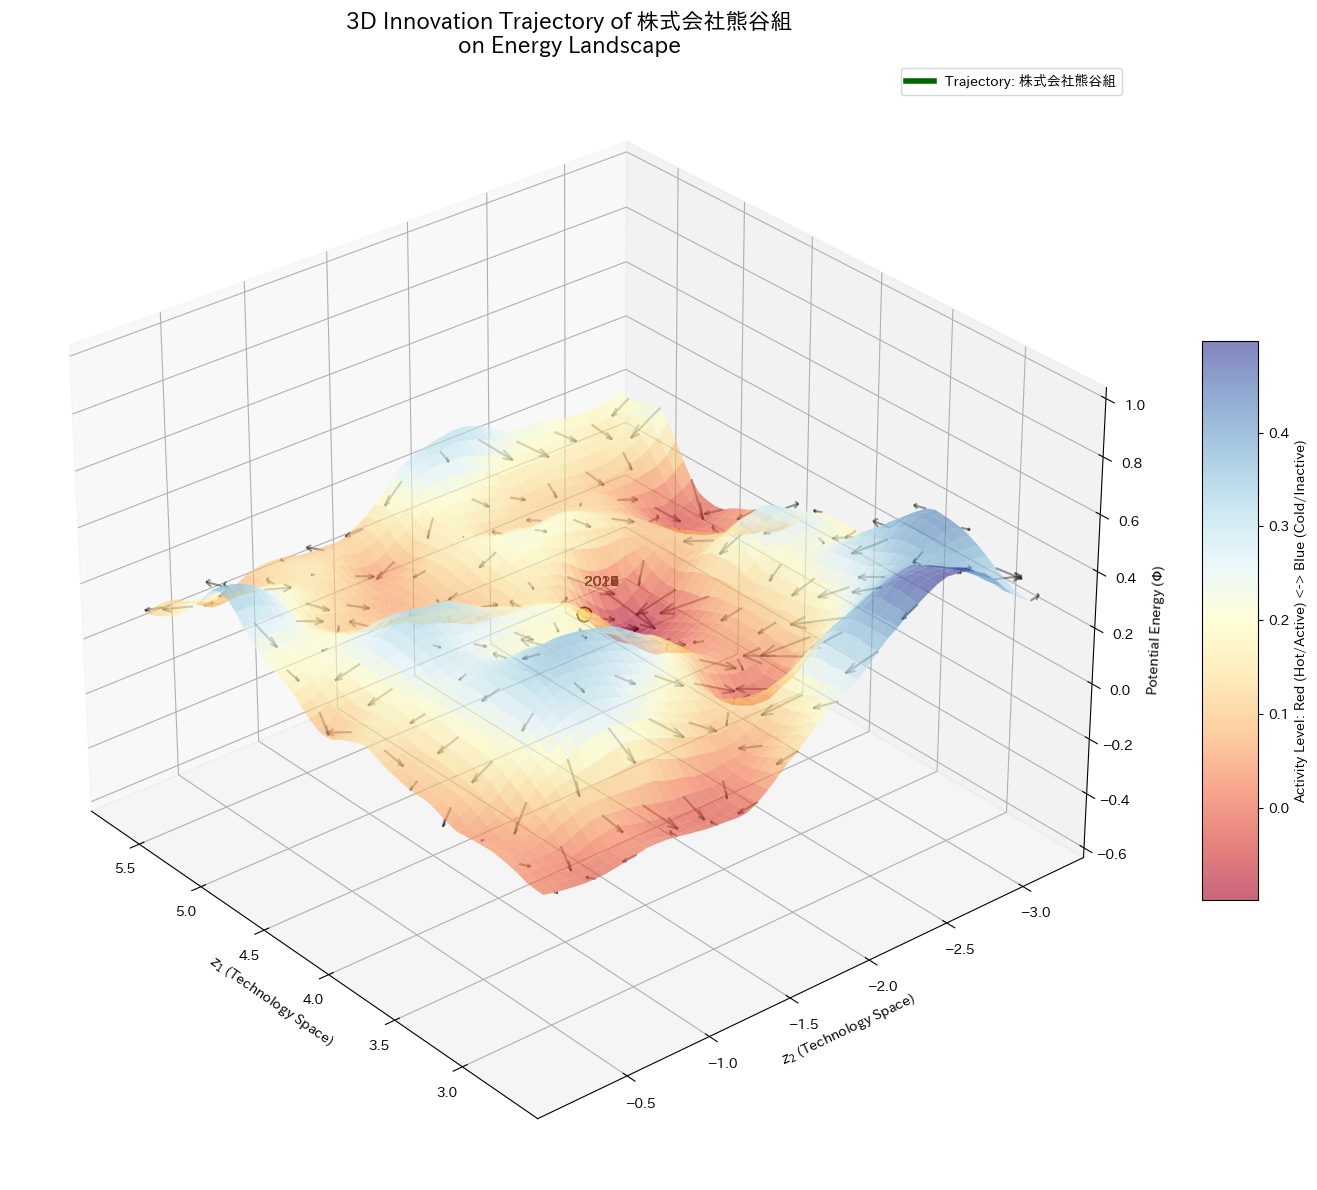

In [51]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_corporate_trajectory_3d(model, graphs, corp_name, c_map, device, res=50):
    """
    特定の企業の技術進化の軌跡を 3D ポテンシャル地形の上にプロットする
    """
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    corp_idx = c_map[corp_name]
    
    # 1. 各年における企業の座標 (z) を取得
    years = sorted(graphs.keys())
    trajectory_z = []
    
    with torch.no_grad():
        for year in years:
            data = graphs[year].to(device)
            # エンコードして潜代表現 z を取得
            z, _, _ = model.encode(data.x, data.edge_index)
            # 特定企業の座標を保存
            trajectory_z.append(z[corp_idx].cpu().numpy())
    
    trajectory_z = np.array(trajectory_z)  # [年数, 2]
    
    # 2. 企業の移動範囲に合わせて描画範囲を自動決定 (少し余白を追加)
    x_min, x_max = trajectory_z[:, 0].min() - 1.5, trajectory_z[:, 0].max() + 1.5
    y_min, y_max = trajectory_z[:, 1].min() - 1.5, trajectory_z[:, 1].max() + 1.5
    
    # 3. ポテンシャル地形の計算
    x_grid = np.linspace(x_min, x_max, res)
    y_grid = np.linspace(y_min, y_max, res)
    X, Y = np.meshgrid(x_grid, y_grid)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    if model.latent_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
        grid_input = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input = grid_tensor

    grid_input.requires_grad_(True)
    phi = potential_net(grid_input)
    # 勾配の計算 (引力の向き用)
    grads = torch.autograd.grad(phi.sum(), grid_input)[0]
    
    Z_display = phi.detach().cpu().numpy().reshape(res, res)
    U = -grads[:, 0].detach().cpu().numpy().reshape(res, res)
    V = -grads[:, 1].detach().cpu().numpy().reshape(res, res)
    W = -np.sqrt(U**2 + V**2) * 0.2

    # 4. 企業の軌跡に対応する「高さ（ポテンシャル値）」を計算
    traj_tensor = torch.tensor(trajectory_z, dtype=torch.float32).to(device)
    if model.latent_dim > 2:
        traj_padding = torch.zeros(traj_tensor.shape[0], model.latent_dim - 2).to(device)
        traj_input = torch.cat([traj_tensor, traj_padding], dim=-1)
    else:
        traj_input = traj_tensor
        
    with torch.no_grad():
        trajectory_phi = potential_net(traj_input).cpu().numpy().flatten()

    # 5. プロット
    fig = plt.figure(figsize=(15, 12))
    ax = fig.add_subplot(111, projection='3d')

    # 地形の描画 (RdYlBu: 赤=人気/谷)
    surf = ax.plot_surface(X, Y, Z_display, cmap='RdYlBu', alpha=0.6, 
                       edgecolor='none', antialiased=True, shade=True)

    # 引力ベクトル (Quiver) の表示
    skip = 4
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Z_display[::skip, ::skip],
              U[::skip, ::skip], V[::skip, ::skip], W[::skip, ::skip],
              length=0.3, color='black', alpha=0.4, pivot='tail')

    # ★ 企業の軌跡をプロット ★
    # 線 (軌跡)
    ax.plot(trajectory_z[:, 0], trajectory_z[:, 1], trajectory_phi, 
            color='darkgreen', linewidth=4, label=f'Trajectory: {corp_name}', zorder=10)
    
    # 点 (各年の位置)
    ax.scatter(trajectory_z[:, 0], trajectory_z[:, 1], trajectory_phi, 
               color='gold', s=100, edgecolors='black', depthshade=False, zorder=11)

    # 年のラベルを追加
    for i, year in enumerate(years):
        ax.text(trajectory_z[i, 0], trajectory_z[i, 1], trajectory_phi[i] + 0.1, 
                str(year), fontsize=10, fontweight='bold')

    # 6. 仕上げ
    offset = np.min(Z_display) - 0.5
    ax.set_zlim(offset, np.max(Z_display) + 0.5)
    ax.set_title(f"3D Innovation Trajectory of {corp_name}\non Energy Landscape", fontsize=16)
    ax.set_xlabel("$z_1$ (Technology Space)")
    ax.set_ylabel("$z_2$ (Technology Space)")
    ax.set_zlabel("Potential Energy ($\Phi$)")

    cbar = fig.colorbar(surf, shrink=0.5, aspect=10)
    cbar.set_label('Activity Level: Red (Hot/Active) <-> Blue (Cold/Inactive)')
    
    ax.view_init(elev=30, azim=140)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 実行例: 竹中工務店の軌跡を可視化
visualize_corporate_trajectory_3d(trained_model_gradient_ode, graphs, "株式会社熊谷組", c_map, device)

Trajectory Range for 株式会社熊谷組: X[4.176, 4.176], Y[-1.687, -1.687]


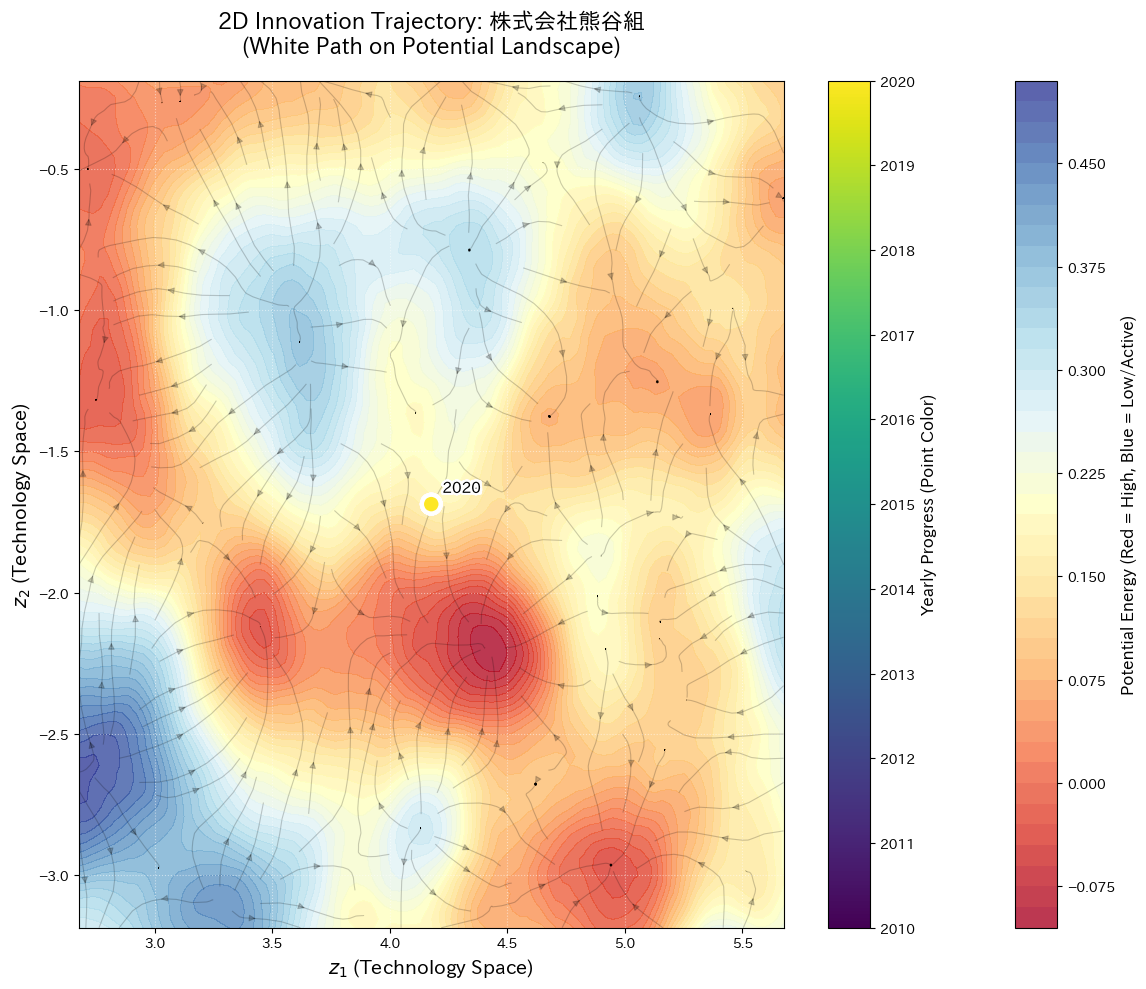

In [80]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects # テキストの縁取り用にインポート

def visualize_corporate_trajectory_2d_v2(model, graphs, corp_name, c_map, device, res=100):
    """
    特定の企業の技術進化の軌跡を 2D ポテンシャル等高線の上にプロットする (修正版)
    """
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    corp_idx = c_map[corp_name]
    
    # 1. 各年における企業の座標 (z) を取得
    years = sorted(graphs.keys())
    trajectory_z = []
    
    with torch.no_grad():
        for year in years:
            data = graphs[year].to(device)
            z, _, _ = model.encode(data.x, data.edge_index)
            trajectory_z.append(z[corp_idx].cpu().numpy())
    
    trajectory_z = np.array(trajectory_z)
    
    # データを正規化していない場合、値が非常に小さかったり大きかったりすることがあるため、
    # 確認のために範囲を出力します（デバッグ用）
    print(f"Trajectory Range for {corp_name}: X[{trajectory_z[:, 0].min():.3f}, {trajectory_z[:, 0].max():.3f}], Y[{trajectory_z[:, 1].min():.3f}, {trajectory_z[:, 1].max():.3f}]")

    # 2. 描画範囲の決定 (マージンを少し広めに設定)
    margin = 1.5
    x_min, x_max = trajectory_z[:, 0].min() - margin, trajectory_z[:, 0].max() + margin
    y_min, y_max = trajectory_z[:, 1].min() - margin, trajectory_z[:, 1].max() + margin
    
    # 3. ポテンシャル地形と勾配の計算
    x_grid = np.linspace(x_min, x_max, res)
    y_grid = np.linspace(y_min, y_max, res)
    X, Y = np.meshgrid(x_grid, y_grid)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    if model.latent_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
        grid_input = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input = grid_tensor

    grid_input.requires_grad_(True)
    phi = potential_net(grid_input)
    grads = torch.autograd.grad(phi.sum(), grid_input)[0]
    
    Z_display = phi.detach().cpu().numpy().reshape(res, res)
    U = -grads[:, 0].detach().cpu().numpy().reshape(res, res)
    V = -grads[:, 1].detach().cpu().numpy().reshape(res, res)

    # 4. プロット
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 【修正1】背景の等高線: カラーマップを反転 ('RdYlBu_r' -> 'RdYlBu')
    # 赤=高ポテンシャル、青=低ポテンシャル(安定/活発)
    contour = ax.contourf(X, Y, Z_display, levels=50, cmap='RdYlBu', alpha=0.8, zorder=1)
    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label('Potential Energy (Red = High, Blue = Low/Active)', fontsize=12)
    
    # 流線の表示 (zorderを下げて背景に徹する)
    ax.streamplot(X, Y, U, V, color=(0, 0, 0, 0.2), linewidth=0.8, density=1.2, zorder=2)

    # 【修正2】企業の軌跡を強調表示
    # 軌跡の線: 黒から「白」に変更、太く、不透明度を上げる
    ax.plot(trajectory_z[:, 0], trajectory_z[:, 1], color='white', 
             linewidth=3.5, alpha=0.9, linestyle='-', zorder=10)
    
    # 時系列に沿った点: サイズを大きく、枠線を太く
    scatter = ax.scatter(trajectory_z[:, 0], trajectory_z[:, 1], 
                         c=range(len(years)), cmap='viridis', s=180, 
                         edgecolors='white', linewidth=3.0, zorder=11)

    # 年のラベル: 白い縁取りを付けて視認性を確保
    txt_effects = [PathEffects.withStroke(linewidth=3, foreground='white')]
    for i, year in enumerate(years):
        txt = ax.annotate(str(year), (trajectory_z[i, 0], trajectory_z[i, 1]),
                     textcoords="offset points", xytext=(8, 8),
                     fontsize=11, fontweight='bold', color='black', zorder=12)
        txt.set_path_effects(txt_effects)

    # 5. 仕上げ
    ax.set_title(f"2D Innovation Trajectory: {corp_name}\n(White Path on Potential Landscape)", fontsize=16, pad=20)
    ax.set_xlabel("$z_1$ (Technology Space)", fontsize=14)
    ax.set_ylabel("$z_2$ (Technology Space)", fontsize=14)
    
    # 年代のカラーバー
    cbar_year = fig.colorbar(scatter, ax=ax, ticks=range(len(years)))
    cbar_year.set_ticklabels(years)
    cbar_year.set_label('Yearly Progress (Point Color)', fontsize=12)

    ax.grid(True, linestyle=':', alpha=0.5, color='white')
    plt.tight_layout()
    plt.show()

# 実行
visualize_corporate_trajectory_2d_v2(trained_model_gradient_ode, graphs, "株式会社熊谷組", c_map, device)

In [70]:
# 座標が動いているか数値で確認
for i, year in enumerate(sorted(graphs.keys())):
    data = graphs[year].to(device)
    z, _, _ = trained_model_gradient_ode.encode(data.x, data.edge_index)
    pos = z[c_map["株式会社熊谷組"]].cpu().detach().numpy()
    print(f"{year}年: {pos}")

2010年: [ 4.176347  -1.6868207]
2011年: [ 4.176347  -1.6868207]
2012年: [ 4.176347  -1.6868207]
2013年: [ 4.176347  -1.6868207]
2014年: [ 4.176347  -1.6868207]
2015年: [ 4.176347  -1.6868207]
2016年: [ 4.176347  -1.6868207]
2017年: [ 4.176347  -1.6868207]
2018年: [ 4.176347  -1.6868207]
2019年: [ 4.176347  -1.6868207]
2020年: [ 4.176347  -1.6868207]


--- Simulation Start: 株式会社熊谷組 ---
Initial Position (2010): [ 4.176347  -1.6868207]
Final Position (Step +10): [ 4.1447434 -2.117626 ]
--- Simulation Complete ---


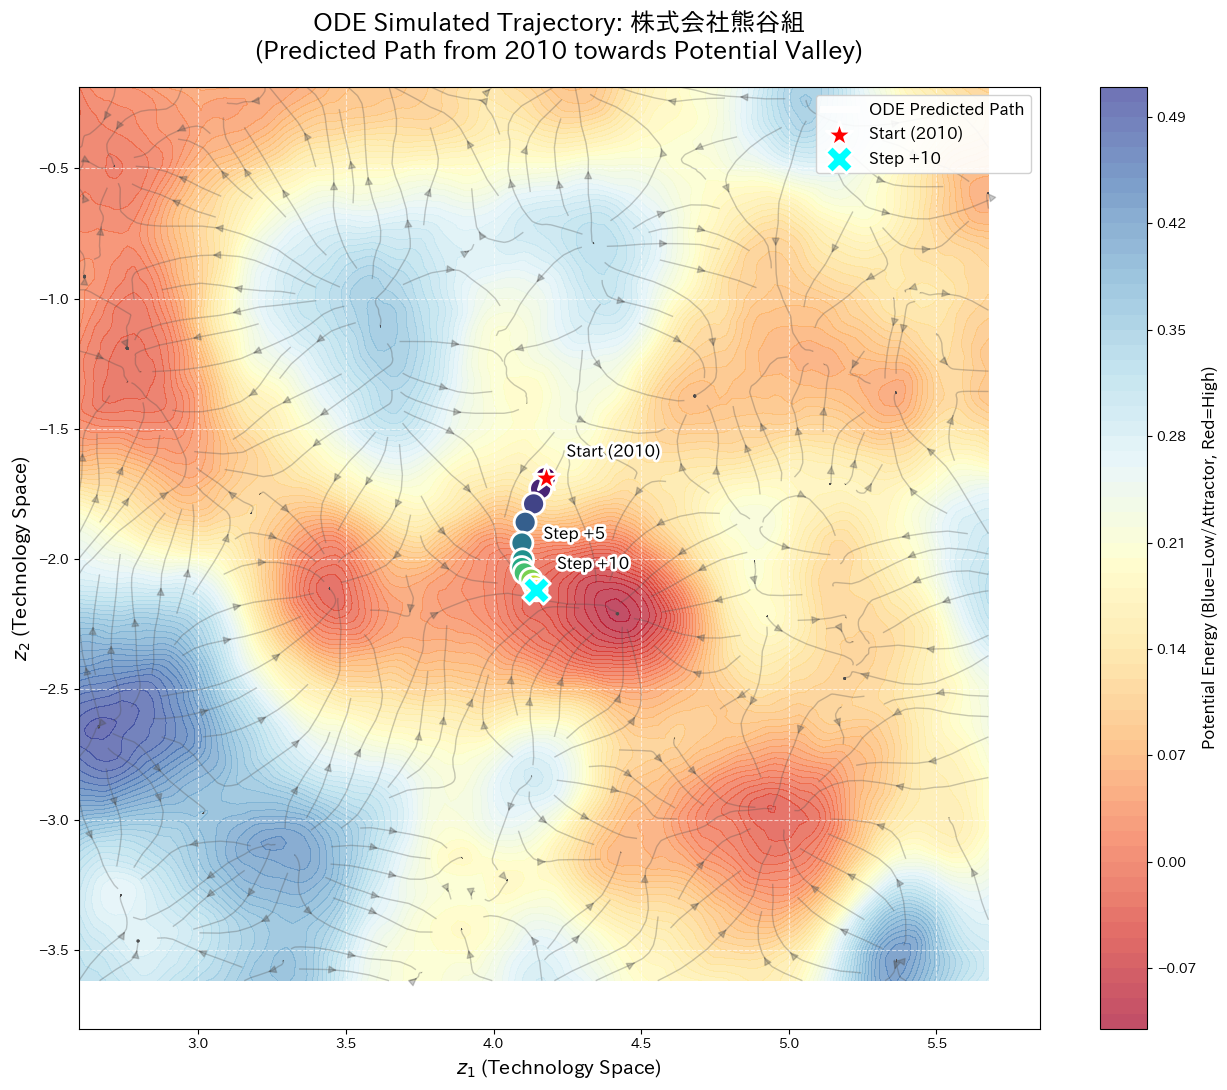

In [76]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects # 視認性向上のため

def visualize_ode_simulated_trajectory(model, graphs, corp_name, c_map, device, start_year=2010, steps=10, res=150):
    """
    特定企業の開始年の位置から、学習済みODEに基づいて将来の軌跡をシミュレーションして可視化する
    """
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    corp_idx = c_map[corp_name]

    print(f"--- Simulation Start: {corp_name} ---")

    # ==========================================
    # 1. シミュレーションによる軌跡生成
    # ==========================================
    trajectory_z = []
    labels = []

    # 始点(Start Year)の潜在ベクトルを取得
    with torch.no_grad():
        # start_yearのデータが存在するか確認
        if start_year not in graphs:
            print(f"Error: {start_year} data not found.")
            return
        data_start = graphs[start_year].to(device)
        z_all, _, _ = model.encode(data_start.x, data_start.edge_index)
        z_current = z_all[corp_idx].unsqueeze(0) # [1, latent_dim] に変形
    
    trajectory_z.append(z_current.cpu().numpy().flatten())
    labels.append(f"Start ({start_year})")
    print(f"Initial Position ({start_year}): {trajectory_z[0]}")

    # ODE予測器を使って、ステップごとに未来の位置を計算
    with torch.no_grad():
        for i in range(1, steps + 1):
            # 現在位置から delta_t=1.0 だけ未来を予測
            # model.temporal_predictor(...) は GradientNeuralODEPredictor の forward を呼び出す
            z_next = model.temporal_predictor(z_current, delta_t=1.0)
            
            trajectory_z.append(z_next.cpu().numpy().flatten())
            labels.append(f"Step +{i}")
            z_current = z_next # 次のステップの出発点にする

    trajectory_z = np.array(trajectory_z)
    print(f"Final Position (Step +{steps}): {trajectory_z[-1]}")
    print("--- Simulation Complete ---")

    # ==========================================
    # 2. 背景（ポテンシャル場と流線）の準備
    # ==========================================
    # 描画範囲の決定 (軌跡が収まるようにマージンを設定)
    margin = 1.5
    x_min, x_max = trajectory_z[:, 0].min() - margin, trajectory_z[:, 0].max() + margin
    y_min, y_max = trajectory_z[:, 1].min() - margin, trajectory_z[:, 1].max() + margin
    
    # グリッド作成
    x_grid = np.linspace(x_min, x_max, res)
    y_grid = np.linspace(y_min, y_max, res)
    X, Y = np.meshgrid(x_grid, y_grid)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    # 潜在次元への対応（2次元より大きい場合パディング）
    if model.latent_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
        grid_input = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input = grid_tensor

    # ポテンシャルと勾配の計算
    grid_input.requires_grad_(True)
    phi = potential_net(grid_input)
    grads = torch.autograd.grad(phi.sum(), grid_input)[0]
    
    Z_display = phi.detach().cpu().numpy().reshape(res, res)
    # 勾配の逆向き（-grads）が引力ベクトル
    U = -grads[:, 0].detach().cpu().numpy().reshape(res, res)
    V = -grads[:, 1].detach().cpu().numpy().reshape(res, res)

    # ==========================================
    # 3. プロット (修正版)
    # ==========================================
    fig, ax = plt.subplots(figsize=(13, 11))
    
    # 背景: ポテンシャル等高線
    contour = ax.contourf(X, Y, Z_display, levels=60, cmap='RdYlBu', alpha=0.7, zorder=1)
    cbar = fig.colorbar(contour, ax=ax)
    cbar.set_label('Potential Energy (Blue=Low/Attractor, Red=High)', fontsize=12, fontweight='bold')
    
    # 背景: 流線
    ax.streamplot(X, Y, U, V, color=(0.3, 0.3, 0.3, 0.3), linewidth=1.0, density=1.5, arrowsize=1.2, zorder=2)

    # --- 軌跡のプロット ---
    # 線: 白と青を重ねて強調
    ax.plot(trajectory_z[:, 0], trajectory_z[:, 1], color='white', 
             linewidth=5, alpha=0.9, linestyle='-', zorder=10, label='ODE Predicted Path')
    ax.plot(trajectory_z[:, 0], trajectory_z[:, 1], color='blue', 
             linewidth=2, alpha=0.6, linestyle=':', zorder=10)

    # 点: 時系列に沿って色を変化させる
    scatter = ax.scatter(trajectory_z[:, 0], trajectory_z[:, 1], 
                         c=range(len(trajectory_z)), cmap='viridis', s=250, 
                         edgecolors='white', linewidth=2.0, zorder=11)

    # 【修正箇所】始点と終点のマーカー (shadow=True を削除)
    # 始点 (Start)
    ax.scatter(trajectory_z[0, 0], trajectory_z[0, 1], c='red', s=400, marker='*', 
               edgecolors='white', linewidth=2, zorder=12, label=labels[0])
    # 終点 (End)
    ax.scatter(trajectory_z[-1, 0], trajectory_z[-1, 1], c='cyan', s=400, marker='X', 
               edgecolors='white', linewidth=2, zorder=12, label=labels[-1])

    # ラベル付け (白い縁取り)
    txt_effects = [PathEffects.withStroke(linewidth=4, foreground='white')]
    idx_to_label = [0, len(labels)//2, len(labels)-1]
    for i in idx_to_label:
        txt = ax.annotate(labels[i], (trajectory_z[i, 0], trajectory_z[i, 1]),
                     textcoords="offset points", xytext=(15, 15),
                     fontsize=12, fontweight='bold', color='black', zorder=13)
        txt.set_path_effects(txt_effects)

    # 仕上げ
    ax.set_title(f"ODE Simulated Trajectory: {corp_name}\n(Predicted Path from 2010 towards Potential Valley)", 
                 fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel("$z_1$ (Technology Space)", fontsize=14, fontweight='bold')
    ax.set_ylabel("$z_2$ (Technology Space)", fontsize=14, fontweight='bold')
    
    # 凡例 (zorder を高く設定)
    ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9, fontsize=12).set_zorder(20)

    ax.grid(True, linestyle='--', alpha=0.6, color='white')
    plt.tight_layout()
    plt.show()

# ==========================================
# 実行コマンド
# ==========================================
# 2010年を始点として、10ステップ先までの軌跡を予測・可視化
visualize_ode_simulated_trajectory(
    trained_model_gradient_ode,  # 学習済みモデル
    graphs,                      # グラフデータ（始点の座標取得用）
    "株式会社熊谷組",            # 対象企業
    c_map,                       # 企業名マッピング
    device,                      # デバイス
    start_year=2010,             # 開始年
    steps=10                     # 予測するステップ数（未来の年数に相当）
)

In [57]:
from collections import Counter
import torch
import numpy as np

def analyze_topic_at_prediction(model, graphs, df, corp_name, c_map, p_map, device, top_k=20):
    """
    予測地点周辺の特許キーワードを抽出し、トピックを分析する
    """
    model.eval()
    corp_idx = c_map[corp_name]
    years = sorted(graphs.keys())
    
    # 1. 2021年の予測座標を計算
    with torch.no_grad():
        z_history = []
        for year in years[-3:]: # 直近3年分を使用
            data = graphs[year].to(device)
            z, _, _ = model.encode(data.x, data.edge_index)
            z_history.append(z)
        
        # 2021年の全ノード予測位置
        z_2021_all = model.predict_future(z_history)
        z_target_pred = z_2021_all[corp_idx] # 対象企業の予測位置
        
        # 最新年(2020年)の全特許の座標
        z_latest = z_history[-1]
        patent_indices = torch.arange(model.num_nodes, device=device)[model.num_nodes - len(p_map):]
        z_patents = z_latest[patent_indices]

    # 2. 潜在空間上での距離計算 (L2ノルム)
    dists = torch.norm(z_patents - z_target_pred, dim=1)
    
    # 最も近い上位K個の特許インデックスを取得
    nearest_val, nearest_idx = torch.topk(dists, k=top_k, largest=False)
    
    # 3. 特許IDからメタデータを逆引き
    idx_to_patent = {idx: name for name, idx in p_map.items()}
    nearest_patent_ids = [idx_to_patent[patent_indices[i].item()] for i in nearest_idx]
    
    # 元のDataFrameからキーワードやタイトルを取得
    # ここでは 'title' や 'abstract' カラムがあることを想定しています
    relevant_df = df[df['patent_number'].isin(nearest_patent_ids)]
    
    print(f"--- {corp_name} の2021年予測領域におけるトピック分析 ---")
    print(f"予測座標: {z_target_pred.cpu().numpy()}")
    print(f"\n近傍にある主要特許タイトル:")
    for title in relevant_df['patent_name'].head(10):
        print(f"- {title}")
        
    return relevant_df

# 実行
relevant_df = analyze_topic_at_prediction(trained_model_gradient_ode, graphs, df, "株式会社熊谷組", c_map, p_map, device)

--- 株式会社熊谷組 の2021年予測領域におけるトピック分析 ---
予測座標: [ 4.158626  -1.7288295]

近傍にある主要特許タイトル:
- モルタルまたはコンクリート用混和材
- 水中騒音の抑制構造および抑制方法
- 吊荷の動揺推定方法
- 車輪装置
- 可搬型打撃装置
- 柱梁接合部の補強構造
- 地中壁
- 施工管理方法及び施工方法
- 無人飛行体を用いた写真測量方法および無人飛行体を用いた写真測量システム
- 地盤の表層の改善に用いられるユニット及び基盤並びに地盤の表層の改善方法


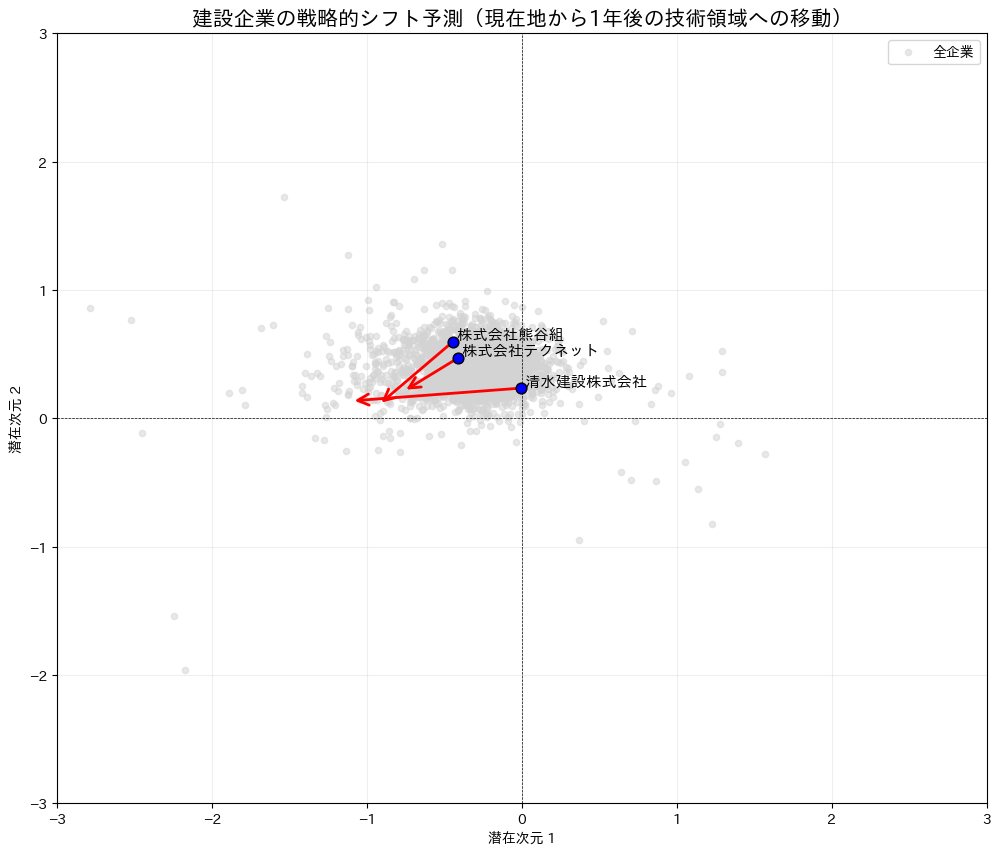

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

def visualize_company_movement_fixed(model, df, device, num_corps, target_companies=None, range_lim=3.0):
    model.eval()
    
    # 1. 企業ノードの現在座標 z_t を取得
    # 学習済みモデルから企業のEmbeddingを取得
    corp_indices = torch.arange(num_corps, device=device)
    corp_features = model.corp_embeddings(corp_indices)
    
    # エンコーダを通して現在の潜在座標 mu を取得
    with torch.no_grad():
        # エンコーダに渡すためのダミーのエッジインデックス
        dummy_edges = torch.zeros((2, 0), dtype=torch.long, device=device)
        mu, _ = model.encoder(corp_features, dummy_edges)
        z_now = mu[:, :2] # 2次元座標

    # 2. 速度ベクトル（勾配）の計算
    # 勾配計算を可能にするために requires_grad=True で作り直す
    z_now_req = z_now.detach().clone().requires_grad_(True)
    
    # 推論モードでも勾配を計算できるように、明示的に grad_enabled(True) にする
    with torch.set_grad_enabled(True):
        # PotentialNet に座標を入れてポテンシャル値を計算
        phi = model.temporal_predictor.potential_net(z_now_req)
        # 速度ベクトル v = -grad(phi)
        # phi.sum() でバッチ全体の勾配を一括計算
        v = -torch.autograd.grad(phi.sum(), z_now_req, create_graph=False)[0]
    
    # 3. 1年後の予測地点の算出
    z_future = z_now + v.detach() * 1.0 # 1年分移動
    
    pos_now = z_now.cpu().numpy()
    pos_fut = z_future.cpu().numpy()
    v_np = v.detach().cpu().numpy()

    # 4. プロット
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 全企業の現在地を薄くプロット
    ax.scatter(pos_now[:, 0], pos_now[:, 1], c='lightgray', s=20, alpha=0.5, label='全企業')

    # 企業名のリストを取得
    # df の重複を除いた企業名がノード ID 0〜num_corps-1 に対応していると想定
    all_corp_names = df['corporation'].explode().unique()[:num_corps] 
    
    if target_companies is None:
        # 指定がなければ移動速度が大きい（戦略シフトが激しい）上位5社を表示
        v_norms = np.linalg.norm(v_np, axis=1)
        target_indices = np.argsort(v_norms)[-5:]
    else:
        # 指定された企業名に一致するインデックスを抽出
        target_indices = [i for i, name in enumerate(all_corp_names) if name in target_companies]

    for i in target_indices:
        p1 = pos_now[i]
        p2 = pos_fut[i]
        name = all_corp_names[i]
        
        # 移動の矢印（現在地 -> 1年後予測）
        ax.annotate('', xy=p2, xytext=p1,
                    arrowprops=dict(arrowstyle='->', lw=2, color='red', mutation_scale=20))
        
        # 現在地の点
        ax.scatter(p1[0], p1[1], c='blue', s=60, edgecolors='black', zorder=5)
        ax.text(p1[0], p1[1], f" {name}", fontsize=11, fontweight='bold', va='bottom')

    ax.set_title("建設企業の戦略的シフト予測（現在地から1年後の技術領域への移動）", fontsize=15)
    ax.set_xlabel("潜在次元 1")
    ax.set_ylabel("潜在次元 2")
    ax.set_xlim(-range_lim, range_lim)
    ax.set_ylim(-range_lim, range_lim)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    ax.axvline(0, color='black', lw=0.5, ls='--')
    ax.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

# 実行
visualize_company_movement_fixed(trained_model_gradient_ode, df, device, 
                                num_corps=num_corps, 
                                target_companies=['株式会社熊谷組', '株式会社テクネット', '清水建設株式会社'])

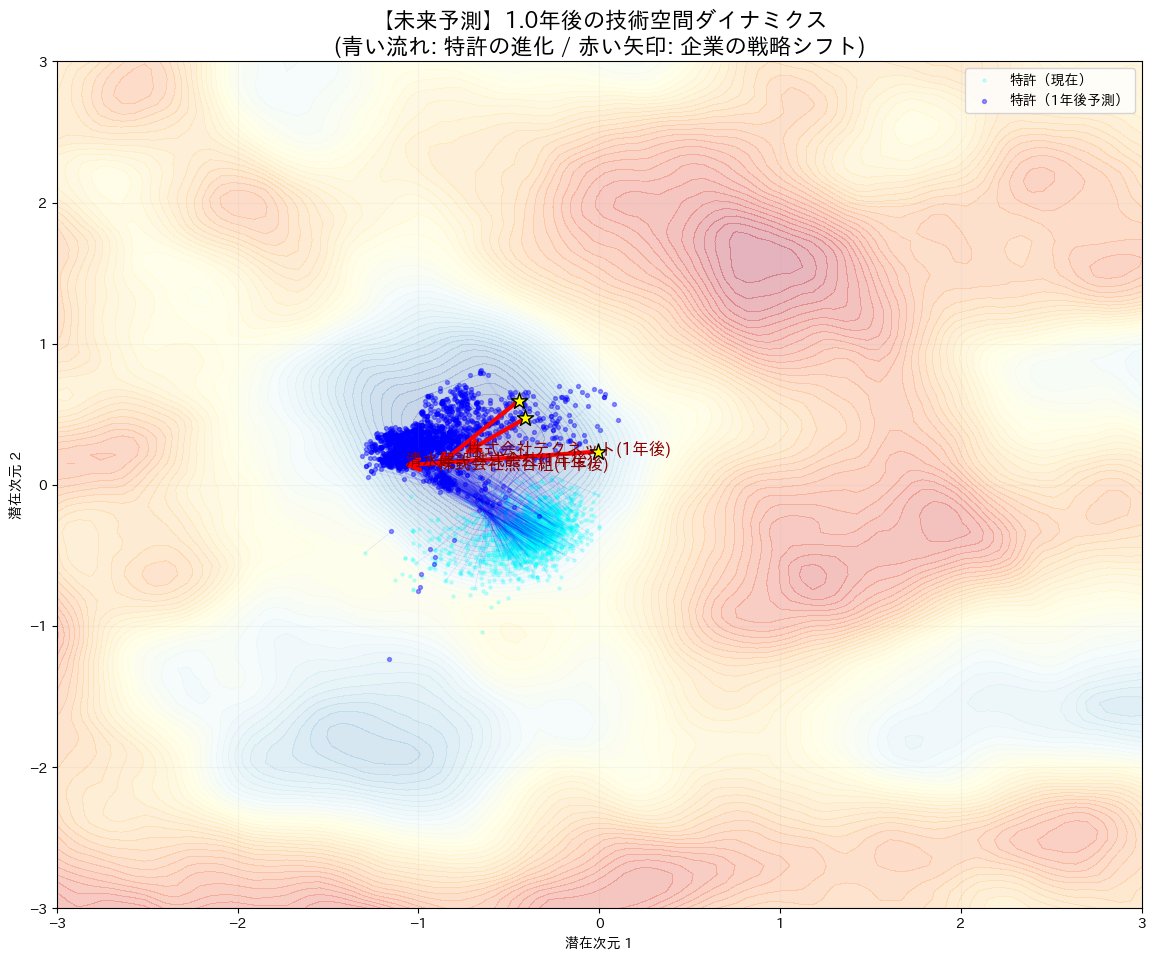

In [30]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

def visualize_future_combined_dynamics(model, df, device, num_corps, target_companies=None, range_lim=3.0, num_patents=1000, time_delta=1.0):
    """
    特許と企業の「1年後の位置」を予測し、空間全体の流れを可視化します。
    """
    model.eval()
    
    # 1. 現在の潜在ベクトルの取得
    corp_indices = torch.arange(num_corps, device=device)
    corp_features = model.corp_embeddings(corp_indices)
    patent_vectors = torch.stack([torch.tensor(v) for v in df['combined_vector'].values[:num_patents]]).to(device)
    
    with torch.no_grad():
        dummy_edges = torch.zeros((2, 0), dtype=torch.long, device=device)
        z_corp_now = model.encoder(corp_features, dummy_edges)[0][:, :2]
        z_patent_now = model.encoder(patent_vectors, dummy_edges)[0][:, :2]

    # 2. 全ノード（企業 + 特許）の速度ベクトルを計算
    def get_future_pos(z_now):
        z_req = z_now.detach().clone().requires_grad_(True)
        with torch.set_grad_enabled(True):
            phi = model.temporal_predictor.potential_net(z_req)
            v = -torch.autograd.grad(phi.sum(), z_req, create_graph=False)[0]
        return (z_now + v.detach() * time_delta).cpu().numpy(), v.detach().cpu().numpy()

    z_corp_fut, v_corp = get_future_pos(z_corp_now)
    z_patent_fut, v_patent = get_future_pos(z_patent_now)
    
    z_corp_now_np = z_corp_now.cpu().numpy()
    z_patent_now_np = z_patent_now.cpu().numpy()

    # 3. 背景ポテンシャルの計算
    res = 100
    x = np.linspace(-range_lim, range_lim, res)
    y = np.linspace(-range_lim, range_lim, res)
    X, Y = np.meshgrid(x, y)
    grid_points = torch.tensor(np.stack([X.flatten(), Y.flatten()], axis=1), dtype=torch.float32).to(device)
    with torch.no_grad():
        phi_grid = model.temporal_predictor.potential_net(grid_points)
        Z = -phi_grid.cpu().numpy().reshape(res, res)

    # 4. プロット
    fig, ax = plt.subplots(figsize=(14, 11))
    
    # A. 背景：ポテンシャル（引力の谷）
    cont = ax.contourf(X, Y, Z, levels=50, cmap='RdYlBu', alpha=0.3)
    
    # B. 特許の移動を表示（点と短い線で「流れ」を表現）
    # 現在地を薄い青、1年後を濃い青
    ax.scatter(z_patent_now_np[:, 0], z_patent_now_np[:, 1], c='cyan', s=5, alpha=0.2, label='特許（現在）')
    for i in range(0, len(z_patent_fut), 5): # 混雑回避のため間引いて線を描画
        ax.plot([z_patent_now_np[i,0], z_patent_fut[i,0]], 
                [z_patent_now_np[i,1], z_patent_fut[i,1]], color='blue', alpha=0.1, lw=0.5)
    ax.scatter(z_patent_fut[:, 0], z_patent_fut[:, 1], c='blue', s=8, alpha=0.4, label='特許（1年後予測）')

    # C. 企業の移動を表示
    all_corp_names = df['corporation'].explode().unique()[:num_corps]
    if target_companies is None:
        target_indices = np.argsort(np.linalg.norm(v_corp, axis=1))[-5:]
    else:
        target_indices = [i for i, name in enumerate(all_corp_names) if name in target_companies]

    for i in target_indices:
        p_now = z_corp_now_np[i]
        p_fut = z_corp_fut[i]
        name = all_corp_names[i]
        
        # 企業の移動矢印
        ax.annotate('', xy=p_fut, xytext=p_now,
                    arrowprops=dict(arrowstyle='->', lw=3, color='red', mutation_scale=20), zorder=10)
        ax.scatter(p_now[0], p_now[1], c='yellow', s=150, edgecolors='black', marker='*', zorder=11)
        ax.text(p_fut[0], p_fut[1], f" {name}(1年後)", fontsize=12, fontweight='bold', color='darkred', zorder=12)

    ax.set_title(f"【未来予測】{time_delta}年後の技術空間ダイナミクス\n(青い流れ: 特許の進化 / 赤い矢印: 企業の戦略シフト)", fontsize=16)
    ax.set_xlabel("潜在次元 1")
    ax.set_ylabel("潜在次元 2")
    ax.set_xlim(-range_lim, range_lim)
    ax.set_ylim(-range_lim, range_lim)
    ax.grid(True, alpha=0.1)
    plt.legend(loc='upper right')
    plt.show()

# 実行
visualize_future_combined_dynamics(trained_model_gradient_ode, df, device, 
                                   num_corps=num_corps, 
                                   target_companies=['株式会社熊谷組', '株式会社テクネット', '清水建設株式会社'],
                                   num_patents=2000, 
                                   time_delta=1.0) # 1.0 = 1年後

In [31]:
def predict_company_patent_probabilities(model, df, device, target_corp_name, num_top=10):
    model.eval()
    
    # 1. 企業と特許の座標を取得
    # 全企業リストを取得（重複排除）
    all_corp_names = df['corporation'].explode().unique()
    try:
        # ターゲット企業のインデックスを特定
        corp_idx = np.where(all_corp_names == target_corp_name)[0][0]
    except IndexError:
        print(f"企業名 '{target_corp_name}' が見つかりません。")
        return

    with torch.no_grad():
        # ダミーのエッジと全ノード分のゼロ行列を準備
        dummy_edges = torch.zeros((2, 0), dtype=torch.long, device=device)
        x_base = torch.zeros(model.num_nodes, model.input_dim, device=device)
        
        # 【修正箇所】戻り値を3つ（z, mu, logvar）で受け取る
        z_all, mu_all, logvar_all = model.encode(x_base, dummy_edges)
        
        # 1年後の企業の予測座標を計算（平均 mu を使用）
        # predict_future はリスト形式の入力を期待するため [mu_all] とします
        z_corp_future = model.predict_future([mu_all])[corp_idx:corp_idx+1, :]
        
        # 特許ノードの座標（企業数以降のすべてのノード）
        z_patents = mu_all[model.num_corps:, :]
        
        # 2. 全特許との組み合わせで確率を計算
        # 予測された企業の1地点に対して、全特許の座標を並べて結合
        z_corp_rep = z_corp_future.repeat(z_patents.size(0), 1)
        
        # Link Predictor に入力するための結合ベクトルを作成
        combined = torch.cat([z_corp_rep, z_patents], dim=-1)
        
        # 内蔵の link_predictor を通してシグモイド関数で確率化
        # 建設業界の特許出願確率 P(link) を算出
        probabilities = torch.sigmoid(model.link_predictor(combined)).squeeze()

    # 3. 結果の整理と表示
    top_probs, top_indices = torch.topk(probabilities, num_top)
    
    print(f"--- {target_corp_name} の1年後 注力予測ランキング ---")
    # 特許データ部分のみの DataFrame を作成（企業数以降）
    df_patents = df.iloc[model.num_corps:].reset_index(drop=True)
    
    for i in range(num_top):
        p_idx = top_indices[i].item()
        prob = top_probs[i].item()
        
        # カラム名に合わせて特許名を取得
        patent_name = "不明"
        for col in ['patent_name', 'title', 'abstract']:
            if col in df.columns:
                patent_name = df.iloc[model.num_corps + p_idx][col]
                break
                
        print(f"順位 {i+1}: 確率 {prob:.2%} | {patent_name}")

# 実行
predict_company_patent_probabilities(model_gradient_ode, df, device, "株式会社熊谷組")

--- 株式会社熊谷組 の1年後 注力予測ランキング ---
順位 1: 確率 59.51% | 把持装置
順位 2: 確率 59.51% | コンクリート打設用時間管理システムとその時間管理方法
順位 3: 確率 59.51% | 原子力発電所建屋の解体方法
順位 4: 確率 59.51% | 掘削土砂の搬出システム
順位 5: 確率 59.51% | コンクリート用メタルフォーム
順位 6: 確率 59.51% | コンクリートの運搬設備
順位 7: 確率 59.51% | 耐爆裂性高強度コンクリートと製造方法
順位 8: 確率 59.51% | コンクリートの養生方法および養生装置
順位 9: 確率 59.51% | 振動抑制装置
順位 10: 確率 59.51% | 鉄筋コンクリート造建物の耐震補強構造及び耐震補強工法


In [32]:
# 学習完了後に実行するコード例
# 変数名をモデルのインスタンス名「model_gradient_ode」に合わせます

target_year = 2016
data_t = graphs[target_year].to(device)
data_t1 = graphs[target_year + 1].to(device)

# 1. 現在の位置 (z_t) を計算
with torch.no_grad():
    z_t, _, _ = model_gradient_ode.encode(data_t.x, data_t.edge_index)
    
    # 2. 未来の予測位置 (z_t1_pred) を計算
    # 簡易的に直近のz_tだけを渡す例（本来は過去3年分必要）
    z_t1_pred = model_gradient_ode.predict_future([z_t])

# 指標の計算
# 引数名を実際の変数名「model_gradient_ode」に変更して呼び出し
metrics = calculate_evidence_metrics(model_gradient_ode, data_t, z_t, z_t1_pred)

print(f"--- {target_year}年時点のエビデンス指標 ---")
print(f"空間分散度 (Separation): {metrics['dispersion']:.4f}")
print(f"理論一致度 (Logic): {metrics['physical_consistency']:.4f}")
print(f"谷への収束率 (Potential Drop): {metrics['potential_convergence']:.4f}")

--- 2016年時点のエビデンス指標 ---
空間分散度 (Separation): 14.6171
理論一致度 (Logic): 0.9933
谷への収束率 (Potential Drop): 0.1892


In [3]:
# ============================================================
# セル9: エンコーダ定義 (既存のまま)
# ============================================================
class SharedVGAEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels * 2, heads=2, concat=False)
        self.conv2 = GATConv(hidden_channels * 2, hidden_channels, heads=2, concat=False)
        self.conv3 = GATConv(hidden_channels, hidden_channels, heads=1, concat=False)
        self.conv_mu = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.conv_logvar = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = nn.Dropout(0.2)
        self.batch_norm1 = nn.BatchNorm1d(hidden_channels * 2)
        self.batch_norm2 = nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.batch_norm1(self.conv1(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.batch_norm2(self.conv2(x, edge_index)))
        x = self.dropout(x)
        x = F.relu(self.conv3(x, edge_index))
        return self.conv_mu(x, edge_index), self.conv_logvar(x, edge_index)

# ============================================================
# セル10 (修正): 高解像度・安定化したPotentialNet
# ============================================================
class PotentialNet(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()

        # 空間の解像度を上げるためのランダム周波数行列
        self.B = nn.Parameter(torch.randn(latent_dim, hidden_dim // 2) * 3.0, requires_grad=False)

        input_features = hidden_dim
        
        # 層を深くし、Dropoutを加えることで一方向の単純な壁になるのを防ぐ
        self.net = nn.Sequential(
            nn.Linear(input_features, hidden_dim * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, z):
        # 座標 z を高周波に変換することで「島」を作りやすくする
        proj = torch.matmul(z, self.B)
        x = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)
        return self.net(x)

    def compute_potential_grid(self, x_range, y_range, resolution=50, device='cpu'):
        """グリッド上でポテンシャルを計算"""
        x = torch.linspace(x_range[0], x_range[1], resolution)
        y = torch.linspace(y_range[0], y_range[1], resolution)
        X, Y = torch.meshgrid(x, y, indexing='ij')
        
        grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1).to(device)
        with torch.no_grad():
            potentials = self.forward(grid_points)
        
        return X.cpu().numpy(), Y.cpu().numpy(), potentials.view(resolution, resolution).cpu().numpy()
    
class GradientODEFunc(nn.Module):
    def __init__(self, potential_net):
        super().__init__()
        self.potential_net = potential_net
        self.scale = nn.Parameter(torch.tensor(0.1))

    def forward(self, t, z):
        with torch.set_grad_enabled(True):
            z_in = z.detach().requires_grad_(True)
            phi = self.potential_net(z_in)
            grad_z = torch.autograd.grad(phi.sum(), z_in, create_graph=True)[0]
        return - torch.tanh(self.scale) * grad_z
    
    def compute_gradient_field(self, X, Y, device='cpu'):
        """グリッド上で勾配ベクトル場を計算"""
        grid_points = torch.tensor(
            np.stack([X.flatten(), Y.flatten()], axis=1), 
            dtype=torch.float32, device=device, requires_grad=True
        )
        
        phi = self.potential_net(grid_points)
        gradients = torch.autograd.grad(phi.sum(), grid_points, create_graph=False)[0]
        
        grad_x = gradients[:, 0].view(X.shape).cpu().numpy()
        grad_y = gradients[:, 1].view(X.shape).cpu().numpy()
        
        return grad_x, grad_y

class GradientNeuralODEPredictor(nn.Module):
    def __init__(self, latent_dim, hidden_dim):
        super().__init__()
        self.potential_net = PotentialNet(latent_dim, hidden_dim)
        self.ode_func = GradientODEFunc(self.potential_net)

    def forward(self, z_current, delta_t=1.0):
        t_span = torch.tensor([0., delta_t], device=z_current.device)
        z_future = odeint(
            self.ode_func, z_current, t_span,
            method='dopri5', rtol=1e-3, atol=1e-3
        )[-1]
        return z_future

# ============================================================
# セル11: 統合VGAEモデル (Gradient ODE専用)
# ============================================================
class UnifiedVGAE(nn.Module):
    def __init__(self, num_nodes, num_corps, input_dim, init_mean=None, hidden_dim=256,
                 latent_dim=2, sequence_length=3):
        super().__init__()
        self.num_nodes = num_nodes
        self.num_corps = num_corps
        self.latent_dim = latent_dim
        self.input_dim = input_dim
        self.sequence_length = sequence_length

        self.corp_embeddings = nn.Embedding(num_corps, input_dim)

        # --- 初期値の修正 ---
        if init_mean is not None:
            # 特許の平均値をベースに、わずかなノイズを加えて初期化
            # data.copy_ を使うことで勾配グラフを維持したまま値を代入
            with torch.no_grad():
                # init_meanをコピーし、各企業ごとに少し散らばらせる（標準偏差0.01程度）
                initial_weights = init_mean.repeat(num_corps, 1) 
                noise = torch.randn_like(initial_weights) * 0.01
                self.corp_embeddings.weight.data.copy_(initial_weights + noise)
        else:
            nn.init.normal_(self.corp_embeddings.weight, mean=0.0, std=0.05)
        # ------------------
        self.encoder = SharedVGAEEncoder(input_dim, hidden_dim, latent_dim)
        self.temporal_predictor = GradientNeuralODEPredictor(latent_dim, hidden_dim)

        self.link_predictor = nn.Sequential(
            nn.Linear(latent_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, 1)
        )

    def get_node_features(self, x, node_indices=None):
        features = x.clone()
        # node_indicesが指定されていない場合は全ノードを対象にする
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        # 企業ノードに該当するインデックスのみを抽出
        corp_idx = node_indices[node_indices < self.num_corps]
        if corp_idx.numel() > 0:
        # マスクではなく、抽出したインデックスを直接使って埋め込みを代入
            features[corp_idx] = self.corp_embeddings(corp_idx)
        return features

    def encode(self, x, edge_index, node_indices=None):
        if node_indices is None:
            node_indices = torch.arange(self.num_nodes, device=x.device)
        x_features = self.get_node_features(x, node_indices)
        mu, logvar = self.encoder(x_features, edge_index)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)
        return mu

    def decode(self, z, edge_index):
        return torch.sigmoid(self.link_predictor(torch.cat([z[edge_index[0]], z[edge_index[1]]], dim=-1))).squeeze()

    def predict_future(self, z_history_list):
        return self.temporal_predictor(z_history_list[-1])
# ============================================================
# セル12: 負例サンプリング関数
# ============================================================
def sample_hard_negatives_v2(model, z, active_corps, active_patents, 
                             pos_set, historical_edges, num_samples=1000):
    """
    潜在空間上で『近くにいるのにリンクがない』ノードを優先的に負例として選ぶ。
    これにより、中心部で固まっているノードを引き剥がす力が最大化される。
    """
    if len(active_corps) == 0 or len(active_patents) == 0:
        return None
    
    neg_edges = []
    
    # 1. 候補ペアを多めにランダム生成 (例: 要求数の5倍)
    # 全くのランダムではなく、現在のアクティブなノードから選ぶ
    candidate_indices_corp = active_corps[torch.randint(0, len(active_corps), (num_samples * 5,))]
    candidate_indices_pat = active_patents[torch.randint(0, len(active_patents), (num_samples * 5,))]

    # 2. 候補ペアの潜在空間上の距離を計算
    # 距離が近いほど『紛らわしい（Hard）』と判断し、引き離す対象にする
    z_c = z[candidate_indices_corp]
    z_p = z[candidate_indices_pat]
    dists = torch.norm(z_c - z_p, dim=1)
    
    # 3. 距離が近い順（昇順）にソート
    sorted_indices = torch.argsort(dists)
    
    # 4. 近いものから順に、正例でも履歴でもないものを採用
    for idx in sorted_indices:
        c_node = candidate_indices_corp[idx].item()
        p_node = candidate_indices_pat[idx].item()
        edge = (c_node, p_node)
        
        if edge not in pos_set and edge not in historical_edges:
            neg_edges.append([c_node, p_node])
            if len(neg_edges) >= num_samples:
                break
                
    if len(neg_edges) == 0:
        return None
        
    return torch.tensor(neg_edges, dtype=torch.long, device=z.device).t().contiguous()


# ============================================================
# セル13 (完全修正版): 損失関数
# ============================================================
def compute_loss_standardized(model, data_t, data_t1, num_corps, 
                              z_history_for_prediction, historical_edges,
                              beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=1.0,
                              potential_weight=0.5, repulsion_weight=5.0):
    """
    統合損失関数
    
    Args:
        model: UnifiedVGAE
        data_t: 現在時刻のグラフデータ
        data_t1: 次時刻のグラフデータ
        num_corps: 企業数
        z_history_for_prediction: リスト [z_{t-2}, z_{t-1}, z_t]
        historical_edges: 履歴エッジのセット
        
    Returns:
        total_loss: スカラー損失
        loss_dict: 各損失の辞書
    """
    try:
        device = data_t.x.device
        node_indices = torch.arange(model.num_nodes, device=device)
        
        # ============================================================
        # 1. 現在時刻 t のエンコード
        # ============================================================
        z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index, node_indices)
        
        # ============================================================
        # 2. 再構成損失 (現在時刻 t)
        # ============================================================
        pos_edge_index_t = data_t.edge_index
        active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
        active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
        pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
        
        neg_edge_index_t = sample_hard_negatives_v2(
            model, z_t, active_corps_t, active_patents_t, 
            pos_set_t, historical_edges, num_samples=500
        )
        
        recon_loss_t = torch.tensor(0.0, device=device)
        if neg_edge_index_t is not None and neg_edge_index_t.size(1) > 0:
            pos_pred_t = model.decode(z_t, pos_edge_index_t)
            neg_pred_t = model.decode(z_t, neg_edge_index_t)
            recon_loss_t = (
                -torch.log(pos_pred_t + 1e-15).mean() * pos_weight 
                - torch.log(1 - neg_pred_t + 1e-15).mean()
            )
        
        # KL損失
        kl_loss_t = -0.5 * torch.mean(
            1 + logvar_t[data_t.active_mask] 
            - mu_t[data_t.active_mask].pow(2) 
            - logvar_t[data_t.active_mask].exp()
        )
        
        # ============================================================
        # 3. ポテンシャル損失（ランクベース）
        # ============================================================
        unique_patents, counts = torch.unique(data_t.edge_index[1], return_counts=True)
        target_phi = torch.zeros(model.num_nodes, 1, device=device)

        # ここで patent_mask を定義する
        patent_mask = (node_indices >= num_corps) & data_t.active_mask

        potential_loss = torch.tensor(0.0, device=device)
        if unique_patents.numel() > 0:
            # ランク計算 (人気なほど大きな値)
            ranks = torch.argsort(torch.argsort(counts.float())).float()
            # 0〜1に正規化後、1.0(不人気/山) 〜 -1.0(人気/谷) に変換
            normalized_target = 1.0 - (ranks / (ranks.max() + 1e-9)) * 2.0
            target_phi[unique_patents] = normalized_target.view(-1, 1)

            predicted_phi = model.temporal_predictor.potential_net(mu_t)
            # アクティブな特許ノードのみで損失を計算
            potential_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])
        
        # ============================================================
        # 4. 未来予測損失（重要な修正箇所）
        # ============================================================
        # z_history_for_prediction がリストであることを確認
        z_t1_pred = model.predict_future(z_history_for_prediction)
        with torch.no_grad():
            _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)

        # 予測位置と実際の次時刻位置のMSE
        latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

        # ============================================================
        # 5. 未来リンク予測損失
        # ============================================================
        pos_edge_index_t1 = data_t1.edge_index
        future_link_loss = torch.tensor(0.0, device=device)
        
        if pos_edge_index_t1.size(1) > 0 and z_history_for_prediction is not None:
            active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
            active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
            pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
            
            neg_t1 = sample_hard_negatives_v2(
                model, z_t1_pred, active_corps_t1, active_patents_t1, 
                pos_set_t1, historical_edges, num_samples=300
            )
            
            if neg_t1 is not None and neg_t1.size(1) > 0:
                future_link_loss = (
                    -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight
                    - torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()
                )

        # ============================================================
        # 6. 特許間反発力損失 (修正版)
        # ============================================================
        # 全ノードに適用すると企業-特許間の引き寄せと衝突するため、特許ノード同士のみに限定
        patent_mask = (node_indices >= num_corps) & data_t.active_mask
        z_patents = z_t[patent_mask]

        repulsion_loss = torch.tensor(0.0, device=device)
        if z_patents.size(0) > 1:
            dist_matrix = torch.cdist(z_patents, z_patents)
            margin = 0.5
            eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
            repulsion_loss = torch.relu(margin - dist_matrix[eye_mask]).mean()

        # ============================================================
        # 6. 総損失
        # ============================================================

        total_loss = (
            recon_loss_t 
            + beta * kl_loss_t 
            + latent_pred_weight * latent_pred_loss 
            + future_link_weight * future_link_loss 
            + potential_weight * potential_loss
            + repulsion_weight * repulsion_loss 
        )
        
        loss_dict = {
            'total_loss': total_loss.item(),
            'recon_loss': recon_loss_t.item(),
            'kl_loss': kl_loss_t.item(),
            'latent_pred_loss': latent_pred_loss.item(),
            'future_link_loss': future_link_loss.item(),
            'potential_loss': potential_loss.item(),
            'repulsion_loss': repulsion_loss.item()
        }
        
        return total_loss, loss_dict
        
    except Exception as e:
        print(f"⚠️ 損失計算エラー: {e}")
        return (torch.tensor(0.0, device=device, requires_grad=True), 
                {'total_loss': 0.0, 'potential_loss': 0.0, 'future_link_loss': 0.0})


def train_model_improved(model, global_graph_dict, num_corps, model_name, 
                        historical_edges, num_epochs=20):
    """
    エビデンス指標（分離度・理論一致度）を統合した改善版学習ループ
    """
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)
    
    years = sorted(global_graph_dict.keys())
    train_years = years[:int(len(years) * 0.7)]
    val_years = years[int(len(years) * 0.7):int(len(years) * 0.85)]
    test_years = years[int(len(years) * 0.85):]
    
    # 指標を保存するための履歴
    history = {
        'train_loss': [], 
        'val_mrr': [], 
        'dispersion': [], # 空間分散度
        'consistency': [] # 理論一致度
    }
    
    # 全正解エッジの収集（既存のまま）
    all_true_edges = set()
    for year_list in [train_years, val_years, test_years]:
        for year in year_list:
            edges = global_graph_dict[year].edge_index.t().tolist()
            all_true_edges.update([tuple(e) for e in edges])
    
    best_val_mrr = 0.0
    best_model_state = None
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        num_batches = 0
        
        # --- 学習：年ごとのループ ---
        for i in range(len(train_years) - 1):
            year_t = train_years[i]
            year_t1 = train_years[i + 1]
            
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            
            # 1. 履歴の構築と現在の z_t の取得
            z_history = []
            for j in range(max(0, i - 2), i + 1):
                with torch.no_grad():
                    data_hist = global_graph_dict[train_years[j]].to(device)
                    z_hist, _, _ = model.encode(data_hist.x, data_hist.edge_index)
                    z_history.append(z_hist)
            
            z_t = z_history[-1] # 現在の位置

            # 2. 損失計算
            optimizer.zero_grad()
            loss, loss_dict = compute_loss_standardized(
                model, data_t, data_t1, num_corps, 
                z_history, historical_edges
            )
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1

            # 3. エビデンス指標の計算（エポックの最後の年で計測）
            if i == len(train_years) - 2:
                with torch.no_grad():
                    z_t1_pred = model.predict_future(z_history) # 1年後の予測位置
                    evidence = calculate_evidence_metrics(model, data_t, z_t, z_t1_pred)
                    history['dispersion'].append(evidence['dispersion'])
                    history['consistency'].append(evidence['physical_consistency'])
        
        avg_train_loss = epoch_loss / max(num_batches, 1)
        history['train_loss'].append(avg_train_loss)
        
        # --- 検証フェーズ（既存のまま） ---
        model.eval()
        val_mrr_list = []
        for i in range(len(val_years) - 1):
            year_t = val_years[i]
            year_t1 = val_years[i + 1]
            data_t = global_graph_dict[year_t].to(device)
            data_t1 = global_graph_dict[year_t1].to(device)
            z_history_val = []
            look_back_years = [y for y in years if y < year_t1][-3:]
            for y in look_back_years:
                with torch.no_grad():
                    data_hist = global_graph_dict[y].to(device)
                    z_h, _, _ = model.encode(data_hist.x, data_hist.edge_index)
                    z_history_val.append(z_h)
            with torch.no_grad():
                z_pred = model.predict_future(z_history_val)
            metrics = compute_ranking_metrics(model, z_pred, data_t1.edge_index, num_corps, all_true_edges)
            if metrics: val_mrr_list.append(metrics['mrr'])
        
        val_mrr = np.mean(val_mrr_list) if val_mrr_list else 0.0
        history['val_mrr'].append(val_mrr)
        
        if val_mrr > best_val_mrr:
            best_val_mrr = val_mrr
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        
        scheduler.step(val_mrr)
        
        # --- ログ出力の強化：損失とエビデンスを同時に表示 ---
        print(f"Epoch {epoch+1:02d}/{num_epochs} | "
              f"Loss: {avg_train_loss:.4f} | "
              f"MRR: {val_mrr:.4f} | "
              f"Disp: {history['dispersion'][-1]:.3f} | "
              f"Consist: {history['consistency'][-1]:.3f}")
    
    if best_model_state:
        model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    
    return model, best_val_mrr, history, time.time() - start_time

# ============================================================
# セル13 (修正版): ランクベース順位制を用いた損失関数
# ============================================================
def compute_loss_standardized(model, data_t, data_t1, num_corps, z_history_for_prediction,
                              historical_edges, beta=0.01, pos_weight=5.0, 
                              latent_pred_weight=1.0, future_link_weight=15.0,
                              potential_weight=10.0, repulsion_weight=5.0):
    device = data_t.x.device
    
    # 0. インデックスとマスクの定義
    node_indices = torch.arange(model.num_nodes, device=device)
    patent_mask = (node_indices >= num_corps) & data_t.active_mask
    
    # 1. エンコード
    z_t, mu_t, logvar_t = model.encode(data_t.x, data_t.edge_index)
    
    # 2. 再構成損失 (t)
    pos_edge_index_t = data_t.edge_index
    active_corps_t = torch.unique(pos_edge_index_t[0][pos_edge_index_t[0] < num_corps])
    active_patents_t = torch.unique(pos_edge_index_t[1][pos_edge_index_t[1] >= num_corps])
    pos_set_t = set(tuple(p.tolist()) for p in pos_edge_index_t.t())
    
    neg_edge_index_t = sample_hard_negatives_v2(model, z_t, active_corps_t, active_patents_t, 
                                                pos_set_t, historical_edges, num_samples=500)
    
    recon_loss_t = torch.tensor(0.0, device=device)
    if neg_edge_index_t is not None:
        pos_pred_t = model.decode(z_t, pos_edge_index_t)
        neg_pred_t = model.decode(z_t, neg_edge_index_t)

        # 【修正箇所】ハブ対策：次数計算の修正
        node_degrees = torch.zeros(model.num_nodes, device=device)
        # edge_index.view(-1) は [エッジ数*2] なので、ones もそのサイズに合わせる
        flat_indices = data_t.edge_index.view(-1)
        ones = torch.ones(flat_indices.size(0), device=device)
        node_degrees.index_add_(0, flat_indices, ones)
        node_degrees += 2.0 
        
        u_idx, v_idx = pos_edge_index_t[0], pos_edge_index_t[1]
        edge_rarity = 1.0 / torch.log(node_degrees[u_idx] * node_degrees[v_idx] + 1e-15)
        
        recon_loss_t = (
            -(torch.log(pos_pred_t + 1e-15) * edge_rarity).mean() * pos_weight 
            - torch.log(1 - neg_pred_t + 1e-15).mean()
        )

    # KL損失
    kl_loss_t = -0.5 * torch.mean(1 + logvar_t[data_t.active_mask] - mu_t[data_t.active_mask].pow(2) - logvar_t[data_t.active_mask].exp())

    # 3. ポテンシャル学習
    unique_patents, counts = torch.unique(data_t.edge_index[1], return_counts=True)
    target_phi = torch.zeros(model.num_nodes, 1, device=device)
    potential_loss = torch.tensor(0.0, device=device)
    
    if unique_patents.numel() > 0:
        ranks = torch.argsort(torch.argsort(counts.float())).float()
        normalized_target = 1.0 - (ranks / (ranks.max() + 1e-9)) * 2.0
        target_phi[unique_patents] = normalized_target.view(-1, 1)
        
        predicted_phi = model.temporal_predictor.potential_net(mu_t)
        potential_loss = F.mse_loss(predicted_phi[patent_mask], target_phi[patent_mask])

    # 4. 未来予測 (ODE)
    z_t1_pred = model.predict_future(z_history_for_prediction)
    with torch.no_grad():
        _, mu_t1_actual, _ = model.encode(data_t1.x, data_t1.edge_index)
    latent_pred_loss = F.mse_loss(z_t1_pred[data_t1.active_mask], mu_t1_actual[data_t1.active_mask])

    # 5. 未来リンク予測
    pos_edge_index_t1 = data_t1.edge_index
    future_link_loss = torch.tensor(0.0, device=device)
    if pos_edge_index_t1.size(1) > 0:
        active_corps_t1 = torch.unique(pos_edge_index_t1[0][pos_edge_index_t1[0] < num_corps])
        active_patents_t1 = torch.unique(pos_edge_index_t1[1][pos_edge_index_t1[1] >= num_corps])
        pos_set_t1 = set(tuple(p.tolist()) for p in pos_edge_index_t1.t())
        neg_t1 = sample_hard_negatives_v2(model, z_t1_pred, active_corps_t1, active_patents_t1, pos_set_t1, historical_edges, num_samples=300)
        if neg_t1 is not None:
            future_link_loss = -torch.log(model.decode(z_t1_pred, pos_edge_index_t1) + 1e-15).mean() * pos_weight - \
                               torch.log(1 - model.decode(z_t1_pred, neg_t1) + 1e-15).mean()

    # 6. 反発力損失
    z_patents = z_t[patent_mask]
    repulsion_loss = torch.tensor(0.0, device=device)
    if z_patents.size(0) > 1:
        dist_matrix = torch.cdist(z_patents, z_patents)
        margin = 0.5
        eye_mask = ~torch.eye(dist_matrix.size(0), dtype=torch.bool, device=device)
        repulsion_loss = torch.relu(margin - dist_matrix[eye_mask]).mean()

    total_loss = (recon_loss_t 
                  + beta * kl_loss_t 
                  + latent_pred_weight * latent_pred_loss 
                  + future_link_weight * future_link_loss 
                  + potential_weight * potential_loss
                  + repulsion_weight * repulsion_loss)
    
    return total_loss, {
        'total_loss': total_loss.item(), 
        'potential_loss': potential_loss.item(), 
        'future_link_loss': future_link_loss.item(),
        'repulsion_loss': repulsion_loss.item()
    }

def calculate_evidence_metrics(model, data_t, z_now, z_future):
    """
    エビデンスとしての正しさを定量化する指標を算出
    """
    model.eval()
    active_mask = data_t.active_mask
    z_active = z_now[active_mask]
    z_fut_active = z_future[active_mask]
    
    # --- 指標1: 空間分散度 (Spatial Dispersion) ---
    centroid = z_active.mean(dim=0)
    dispersion = torch.mean(torch.sum((z_active - centroid)**2, dim=1)).item()
    
    # --- 指標2: 物理的一致度 (Cosine Similarity to Gradient) ---
    # 1. ODEによる実際の移動ベクトル
    v_actual = z_fut_active - z_active
    
    # 2. ポテンシャル場から計算される理論上の引力ベクトル (-grad Phi)
    z_req = z_active.detach().clone().requires_grad_(True)
    with torch.set_grad_enabled(True):
        phi = model.temporal_predictor.potential_net(z_req)
        v_theoretical = -torch.autograd.grad(phi.sum(), z_req)[0]
    
    # 3. 2つのベクトルの向きの一致度 (Cosine Similarity)
    cos_sim = F.cosine_similarity(v_actual, v_theoretical, dim=1)
    avg_consistency = cos_sim.mean().item()
    
    # --- 指標3: 谷への収束率 (Potential Drop) ---
    # 移動によってポテンシャルがどれだけ下がったか（＝より活性領域へ近づいたか）
    with torch.no_grad():
        phi_now = model.temporal_predictor.potential_net(z_active)
        phi_future = model.temporal_predictor.potential_net(z_fut_active)
        # ポテンシャルが低下（エネルギー安定）した割合
        drop_rate = torch.mean((phi_now - phi_future) / (torch.abs(phi_now) + 1e-6)).item()

    return {
        "dispersion": dispersion,         # 数値が大きいほど分離が良い
        "physical_consistency": avg_consistency, # 1.0に近いほど理論通り
        "potential_convergence": drop_rate # 正の値なら「谷に向かって移動」している
    }

# ============================================================
# メイン実行：Gradient Neural ODE のみの学習
# ============================================================
print(">>> Gradient Neural ODE の学習を開始します...")

model_gradient_ode = UnifiedVGAE(
    num_nodes=total_n, num_corps=num_corps, input_dim=len(df.iloc[0]['combined_vector']),
    hidden_dim=128, latent_dim=2, sequence_length=3
).to(device)

trained_model_gradient_ode, best_mrr_gradient_ode, history_gradient_ode, time_gradient_ode = train_model_improved(
    model_gradient_ode, graphs, num_corps, "VGAE+GradientODE_RankBased", historical_edges, num_epochs=30
)

print(f"\n学習完了: VGAE + Gradient ODE (順位制ターゲット)")
print(f"Best Validation MRR: {best_mrr_gradient_ode:.4f}")

>>> Gradient Neural ODE の学習を開始します...
Epoch 01/30 | Loss: 75.2393 | MRR: 0.0515 | Disp: 44.547 | Consist: 0.942
Epoch 02/30 | Loss: 78.7066 | MRR: 0.0486 | Disp: 54.061 | Consist: 0.932
Epoch 03/30 | Loss: 70.3842 | MRR: 0.0523 | Disp: 34.755 | Consist: 0.944
Epoch 04/30 | Loss: 55.5192 | MRR: 0.0535 | Disp: 30.459 | Consist: 0.944
Epoch 05/30 | Loss: 58.4835 | MRR: 0.0493 | Disp: 30.223 | Consist: 0.951
Epoch 06/30 | Loss: 49.9945 | MRR: 0.0539 | Disp: 18.815 | Consist: 0.951
Epoch 07/30 | Loss: 47.1116 | MRR: 0.0508 | Disp: 30.034 | Consist: 0.960
Epoch 08/30 | Loss: 43.6525 | MRR: 0.0498 | Disp: 14.861 | Consist: 0.953
Epoch 09/30 | Loss: 41.2708 | MRR: 0.0469 | Disp: 13.245 | Consist: 0.957
Epoch 10/30 | Loss: 35.9690 | MRR: 0.0477 | Disp: 9.683 | Consist: 0.960
Epoch 11/30 | Loss: 33.4851 | MRR: 0.0453 | Disp: 10.750 | Consist: 0.958
Epoch 12/30 | Loss: 32.3838 | MRR: 0.0502 | Disp: 10.503 | Consist: 0.970
Epoch 13/30 | Loss: 31.5709 | MRR: 0.0462 | Disp: 8.040 | Consist: 0.970
Epo

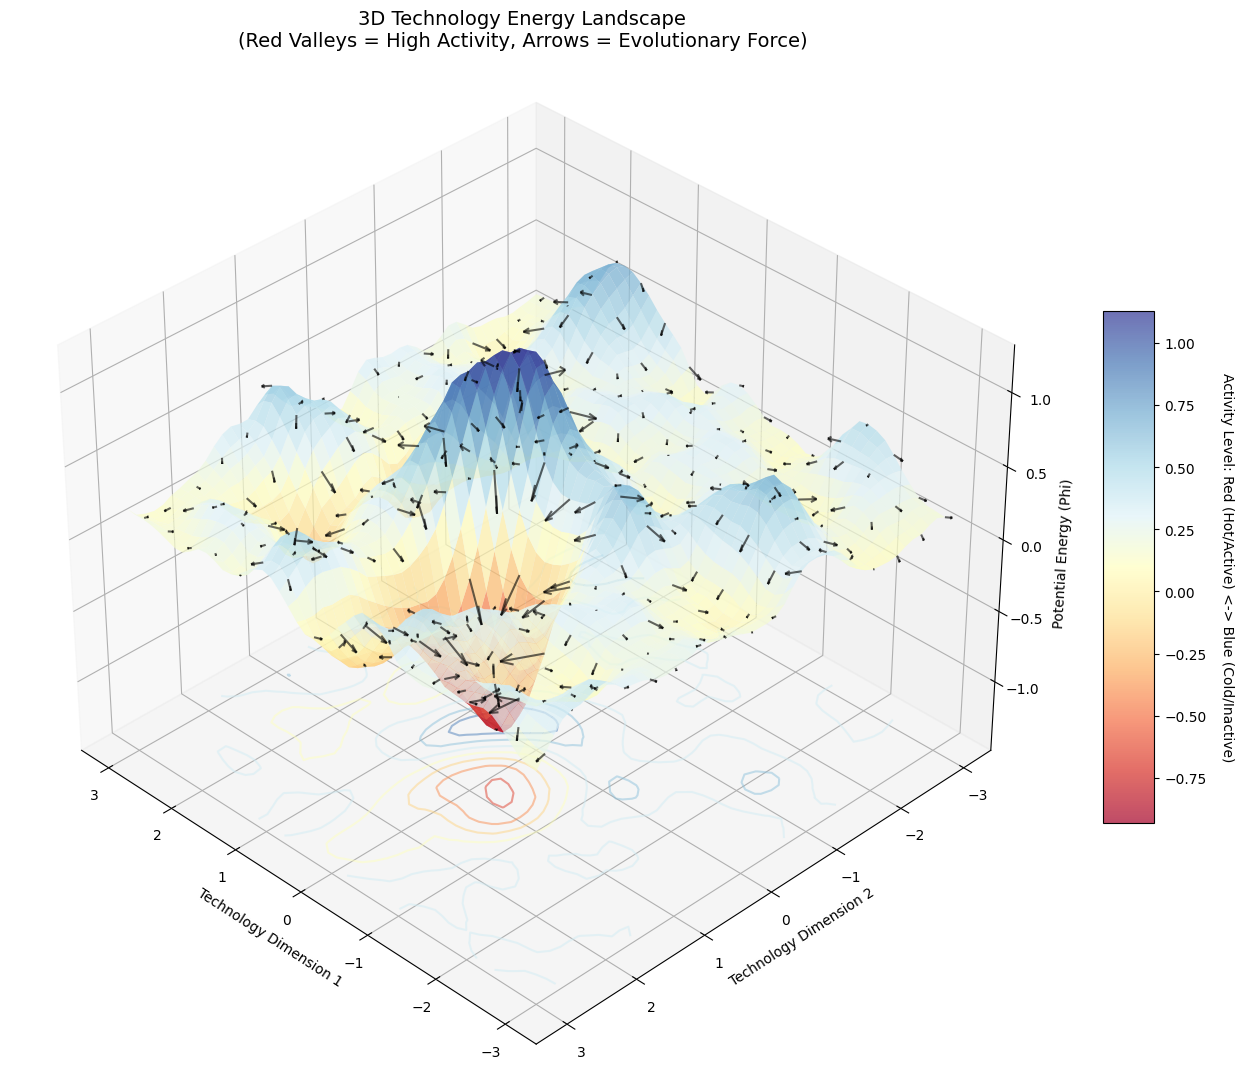

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_potential_3d_quiver_only(model, device, res=50, range_lim=3.0):
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    
    # 1. グリッド生成
    x = np.linspace(-range_lim, range_lim, res)
    y = np.linspace(-range_lim, range_lim, res)
    X, Y = np.meshgrid(x, y)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device)
    
    # latent_dimに合わせて入力整形
    if model.latent_dim > 2:
        padding = torch.zeros(grid_tensor.shape[0], model.latent_dim - 2).to(device)
        grid_input = torch.cat([grid_tensor, padding], dim=-1)
    else:
        grid_input = grid_tensor

    # 2. ポテンシャルと勾配の計算
    grid_input.requires_grad_(True)
    phi = potential_net(grid_input)
    # gradsは dPhi/dz (上り坂の方向)
    grads = torch.autograd.grad(phi.sum(), grid_input)[0]
    
    # 【修正1】高さデータの変更
    # -phi ではなく phi そのままを使う（人気=-1.0/谷, 不人気=1.0/山）
    Z_display = phi.detach().cpu().numpy().reshape(res, res)

    # 【修正2】ベクトルの向きの変更
    # 物理的な引力（下り坂の方向）を表現するため、マイナスをかける (-grad Phi)
    U = -grads[:, 0].detach().cpu().numpy().reshape(res, res)
    V = -grads[:, 1].detach().cpu().numpy().reshape(res, res)
    
    # 【修正3】垂直方向の演出
    # 谷に吸い込まれるような視覚効果を出すため、Wを負の勾配強度に
    W = -np.sqrt(U**2 + V**2) * 0.2

    # 4. プロット
    fig = plt.figure(figsize=(14, 11))
    ax = fig.add_subplot(111, projection='3d')

    # 地形の描画: RdYlBu (数値が低い=-1/谷=Red, 数値が高い=1/山=Blue)
    surf = ax.plot_surface(X, Y, Z_display, cmap='RdYlBu', alpha=0.7, 
                       edgecolor='none', antialiased=True, shade=True)

    # 底面への等高線投影
    offset = np.min(Z_display) - 0.5
    ax.contour(X, Y, Z_display, zdir='z', offset=offset, cmap='RdYlBu', alpha=0.5)  

    # ベクトル（引力場）の表示
    skip = 3 
    ax.quiver(X[::skip, ::skip], Y[::skip, ::skip], Z_display[::skip, ::skip],
              U[::skip, ::skip], V[::skip, ::skip], W[::skip, ::skip],
              length=0.2, color='black', alpha=0.6, pivot='tail', arrow_length_ratio=0.3)

    # 5. 仕上げ
    ax.set_zlim(offset, np.max(Z_display) + 0.1)
    ax.set_title("3D Technology Energy Landscape\n(Red Valleys = High Activity, Arrows = Evolutionary Force)", fontsize=14)
    ax.set_xlabel("Technology Dimension 1")
    ax.set_ylabel("Technology Dimension 2")
    ax.set_zlabel("Potential Energy (Phi)")

    # カラーバーのラベルを分かりやすく変更
    cbar = fig.colorbar(surf, shrink=0.5, aspect=10)
    cbar.set_label('Activity Level: Red (Hot/Active) <-> Blue (Cold/Inactive)', rotation=270, labelpad=20)
    
    ax.view_init(elev=35, azim=135)
    plt.tight_layout()
    plt.show()

# 実行
visualize_potential_3d_quiver_only(trained_model_gradient_ode, device)

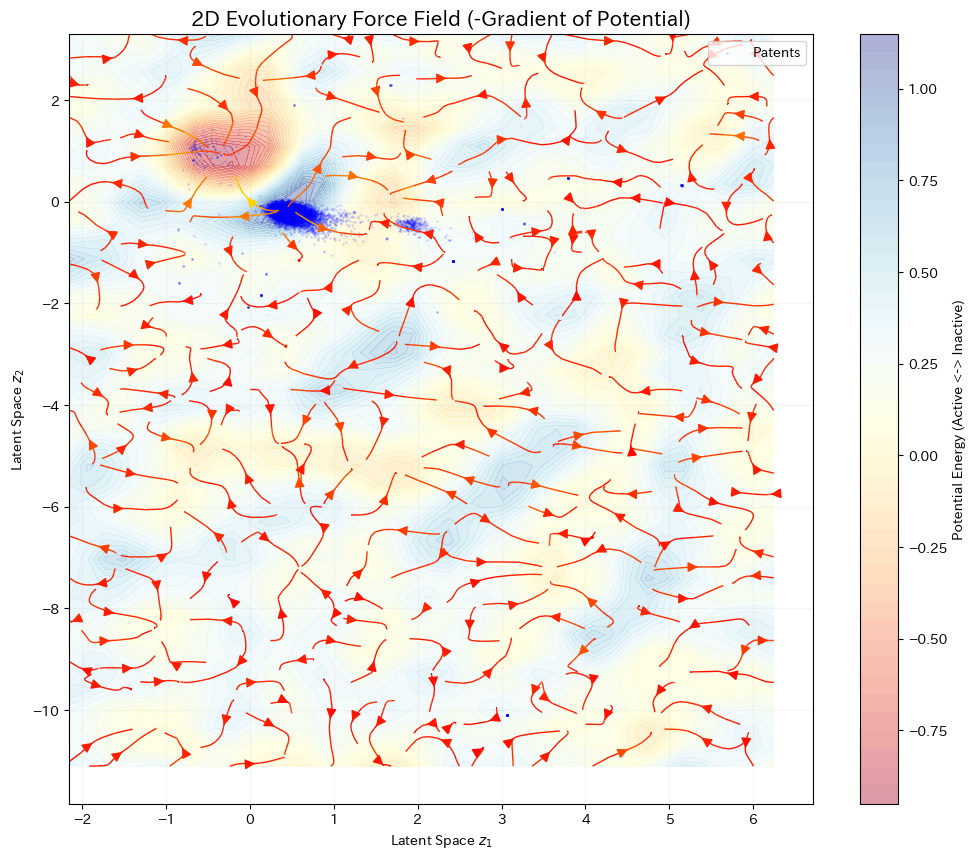

In [9]:
def visualize_potential_2d_with_vectors(model, data_t, device, res=40):
    model.eval()
    potential_net = model.temporal_predictor.potential_net
    
    # 1. 描画範囲の決定
    with torch.no_grad():
        z, _, _ = model.encode(data_t.x.to(device), data_t.edge_index.to(device))
    z_np = z.cpu().numpy()
    x_min, x_max = z_np[:, 0].min() - 1.0, z_np[:, 0].max() + 1.0
    y_min, y_max = z_np[:, 1].min() - 1.0, z_np[:, 1].max() + 1.0

    # 2. グリッドでのポテンシャルと勾配の計算
    x = np.linspace(x_min, x_max, res)
    y = np.linspace(y_min, y_max, res)
    X, Y = np.meshgrid(x, y)
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32).to(device).requires_grad_(True)
    
    phi = potential_net(grid_tensor)
    grads = torch.autograd.grad(phi.sum(), grid_tensor)[0]
    
    Z = phi.detach().cpu().numpy().reshape(res, res)
    # 引力ベクトル (-grad Phi)
    U = -grads[:, 0].detach().cpu().numpy().reshape(res, res)
    V = -grads[:, 1].detach().cpu().numpy().reshape(res, res)

    # 3. プロット
    plt.figure(figsize=(12, 10))
    
    # 背景ポテンシャル
    cp = plt.contourf(X, Y, Z, levels=50, cmap='RdYlBu', alpha=0.4)
    plt.colorbar(cp, label='Potential Energy (Active <-> Inactive)')
    
    # 流線（ベクトル場）の描画
    magnitude = np.sqrt(U**2 + V**2)
    plt.streamplot(X, Y, U, V, color=magnitude, cmap='autumn', linewidth=1, density=1.2, arrowsize=1.5)

    # 特許ノードを薄く表示
    z_patents = z_np[model.num_corps:]
    plt.scatter(z_patents[:, 0], z_patents[:, 1], c='blue', s=1, alpha=0.1, label='Patents')

    plt.title("2D Evolutionary Force Field (-Gradient of Potential)", fontsize=15)
    plt.xlabel("Latent Space $z_1$")
    plt.ylabel("Latent Space $z_2$")
    plt.legend(loc='upper right')
    plt.grid(alpha=0.1)
    plt.show()

# 実行
last_year = sorted(graphs.keys())[-1]
visualize_potential_2d_with_vectors(trained_model_gradient_ode, graphs[last_year], device)